# FTT

### FFT Example from SciPy:
https://docs.scipy.org/doc/scipy/reference/tutorial/fft.html

In [1]:
#import packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.fftpack
import os
import csv
import re
import glob

y shape: (200,)
yf shape: (200,)


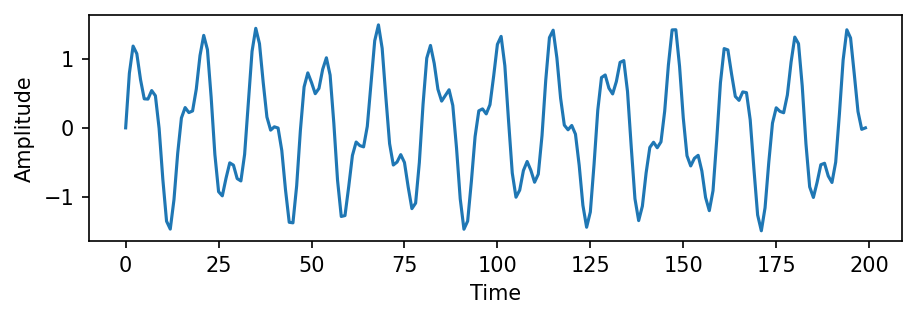

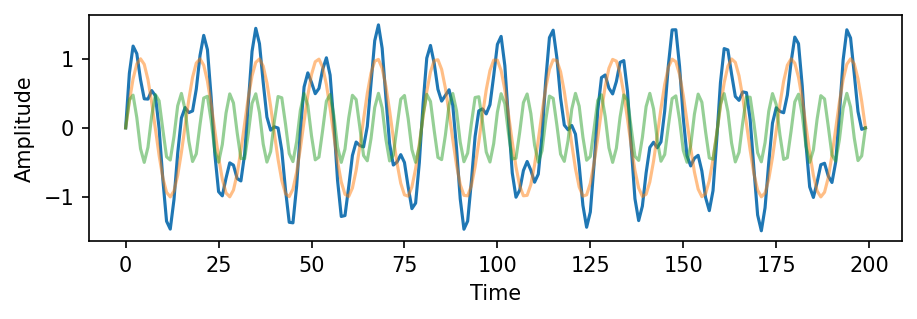

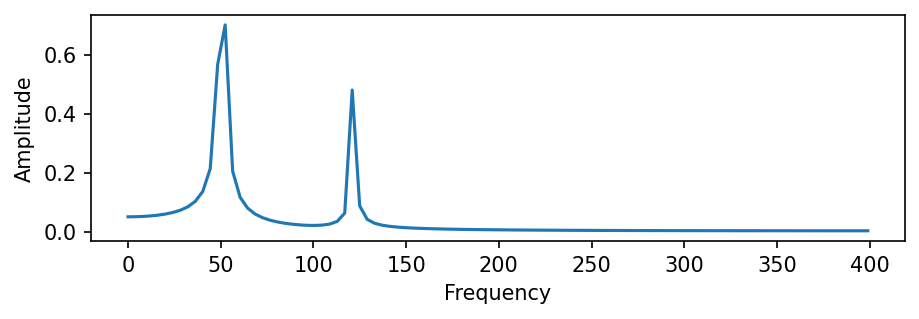

In [2]:
# Number of sample points
N = 200
# sample spacing
T = 1.0 / 800.0
x = np.linspace(0.0, N*T, N)
y1= np.sin(50.0 * 2.0*np.pi*x)
y2= 0.5*np.sin(120.0 * 2.0*np.pi*x)
y = np.sin(50.0 * 2.0*np.pi*x) + 0.5*np.sin(120.0 * 2.0*np.pi*x)
print('y shape: '+str(y.shape))

yf = scipy.fftpack.fft(y)
#It gives the real and the imaginary values, so we use the (abs) to get the real ones
xf = np.linspace(0.0, 1.0//(2.0*T), N//2)
y_axis=2.0/N * np.abs(yf[:N//2])
print('yf shape: '+str(yf.shape))

plt.figure(figsize=(7,2), dpi=150)
plt.plot(y)
plt.ylabel('Amplitude')
plt.xlabel('Time')
plt.show()

plt.figure(figsize=(7,2), dpi=150)
plt.plot(y)
plt.plot(y1, alpha=0.5)
plt.plot(y2, alpha=0.5)
plt.ylabel('Amplitude')
plt.xlabel('Time')
plt.show()
fig, ax = plt.subplots(figsize=(7,2), dpi=150)
ax.plot(xf, 2.0/N * np.abs(yf[:N//2]))
plt.ylabel('Amplitude')
plt.xlabel('Frequency')
plt.show()

### FTT With Lukas on my Kymograph Data

We tried the hanning algorithm to avoid border effects of the FT.
https://www.cbcity.de/die-fft-mit-python-einfach-erklaert
But later decided not to use it for long waves.

In [2]:
#import packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.fftpack

#load data
csv_filepath='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-07-01_10-50-18_control_worm2_spline_K.csv'
K = np.genfromtxt(csv_filepath, delimiter=',')
#to remove nan rows in the data
K=K[~np.isnan(K).any(axis=1)]

#### Show oscillations for different segments

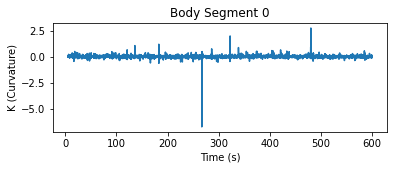

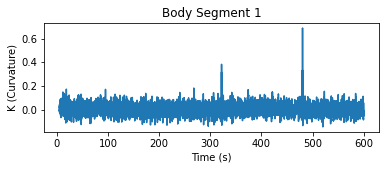

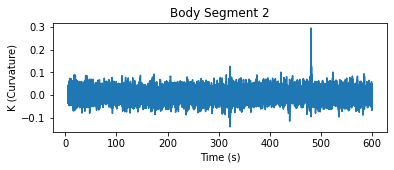

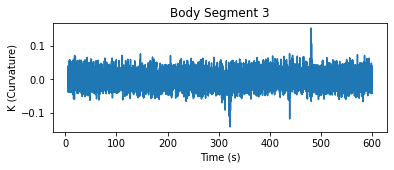

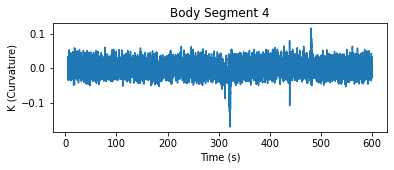

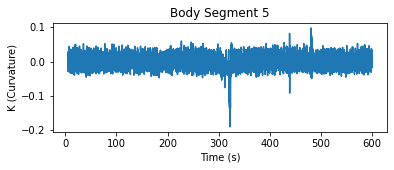

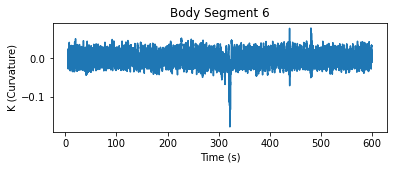

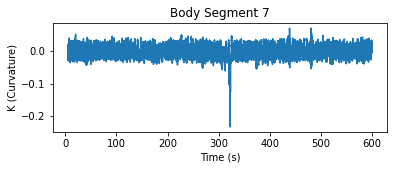

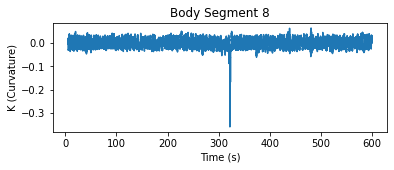

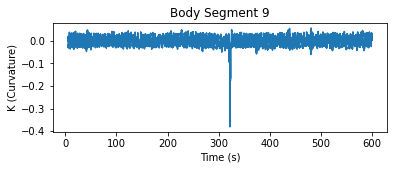

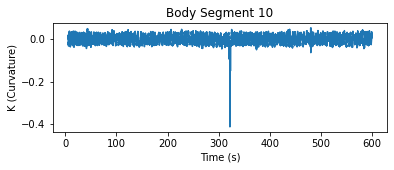

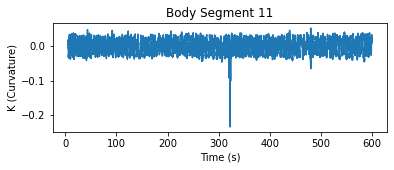

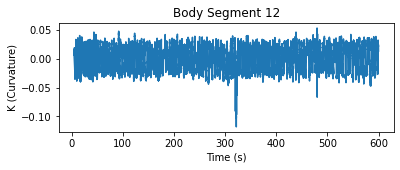

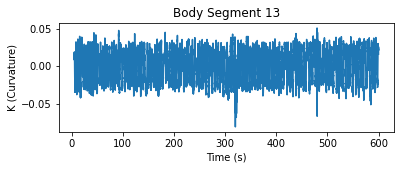

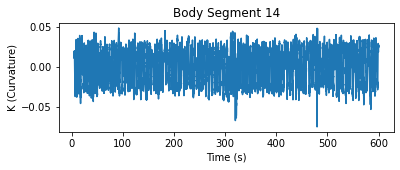

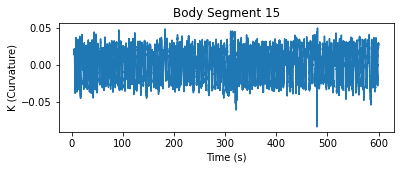

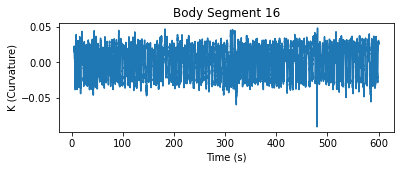

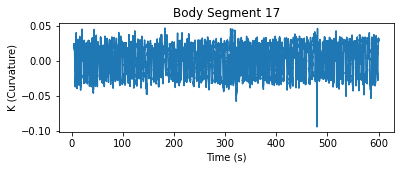

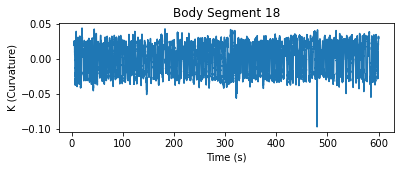

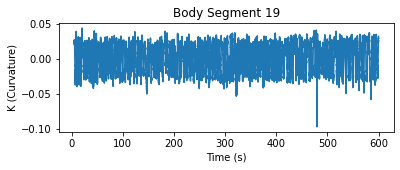

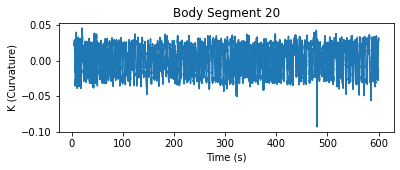

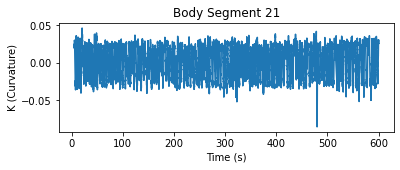

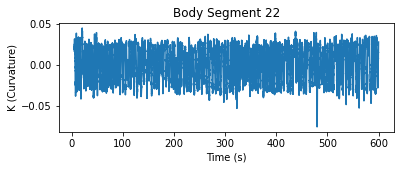

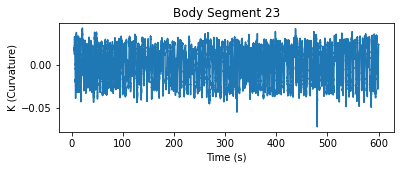

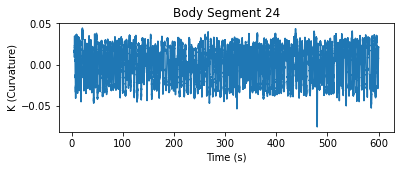

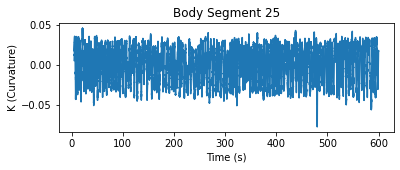

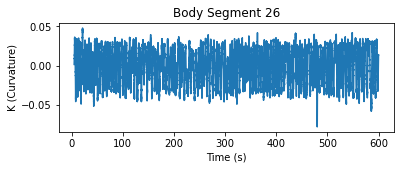

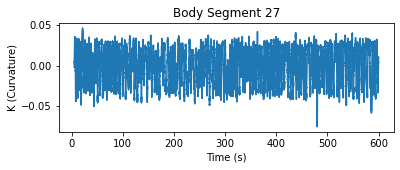

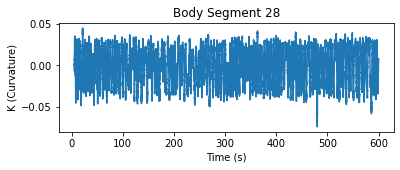

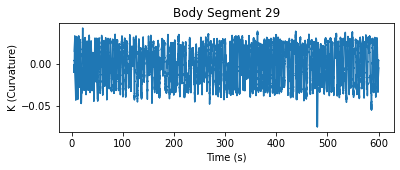

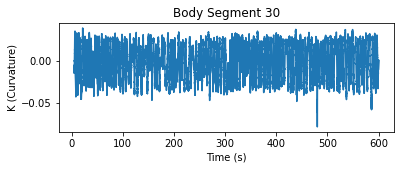

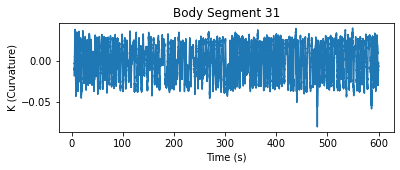

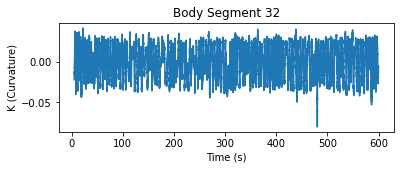

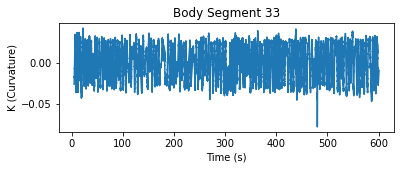

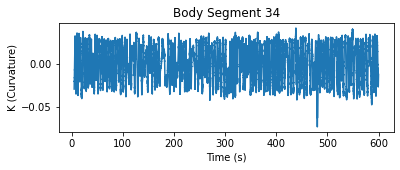

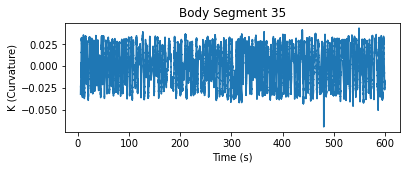

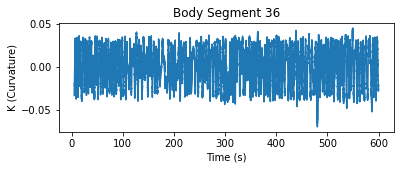

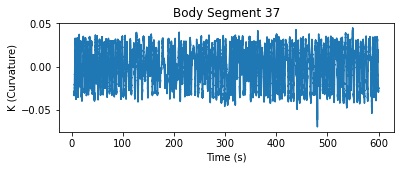

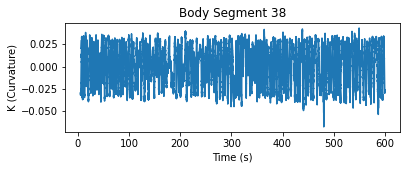

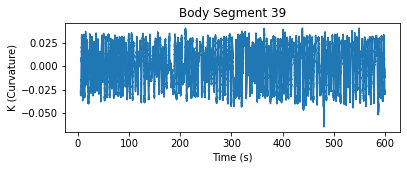

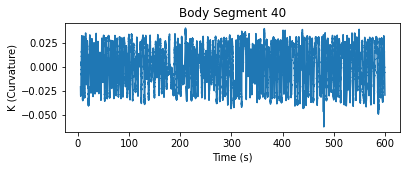

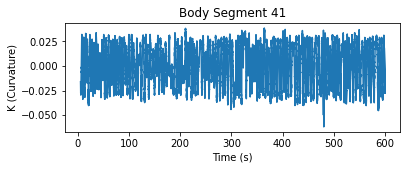

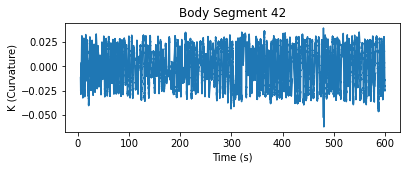

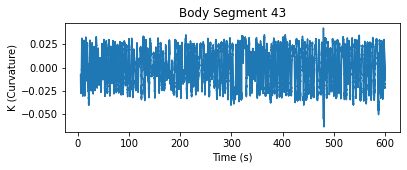

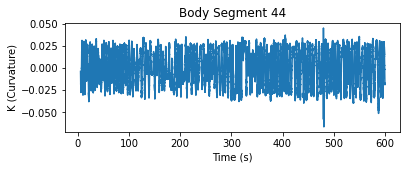

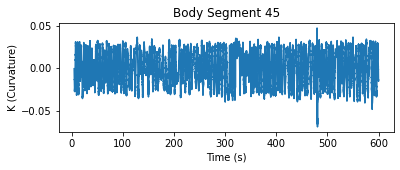

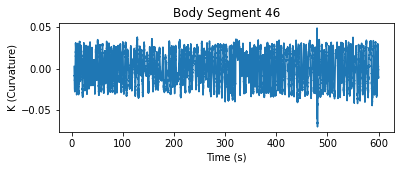

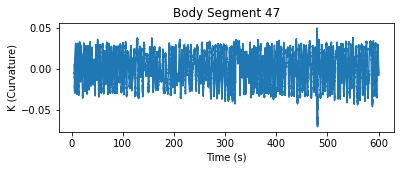

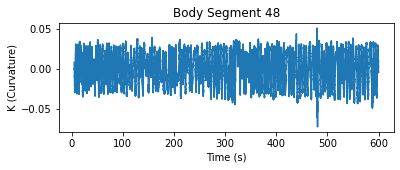

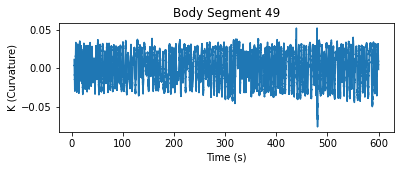

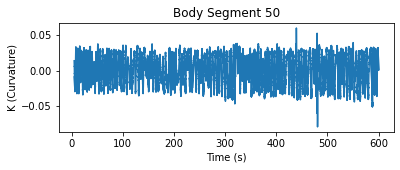

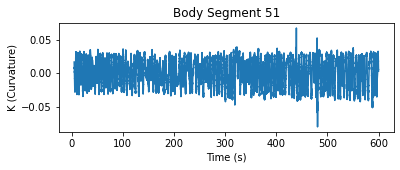

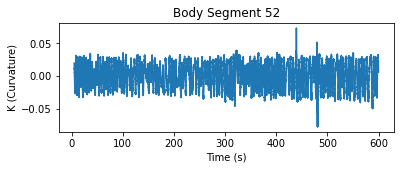

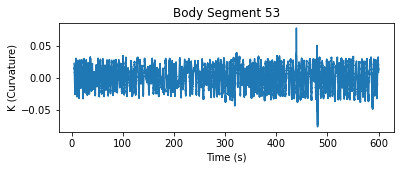

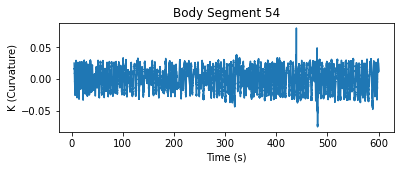

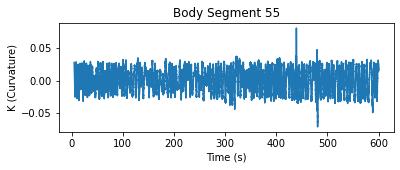

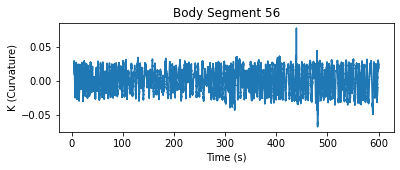

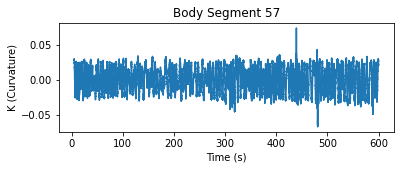

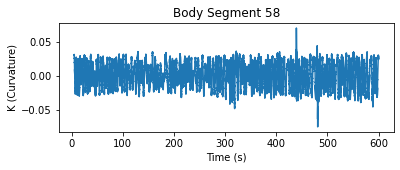

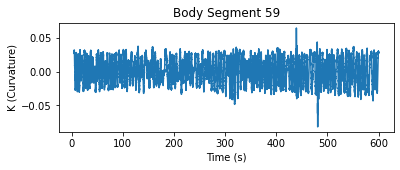

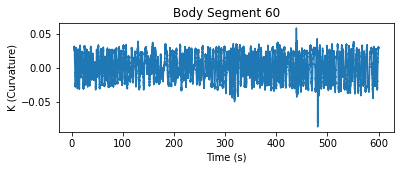

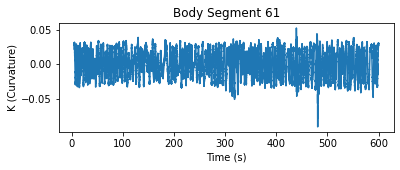

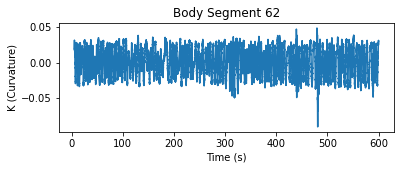

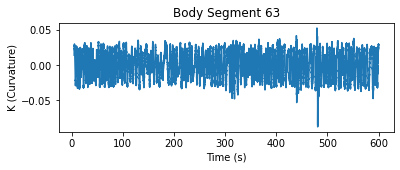

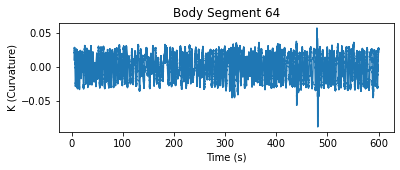

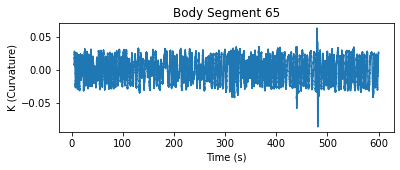

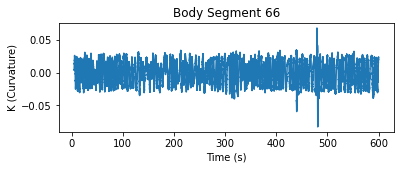

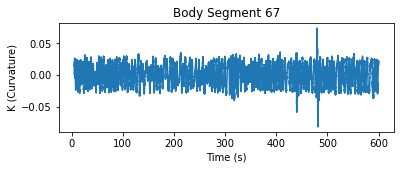

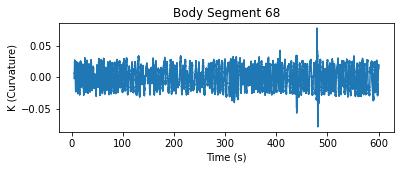

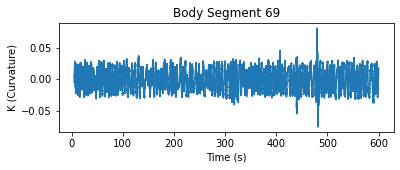

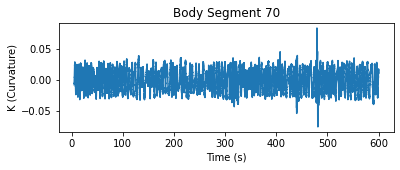

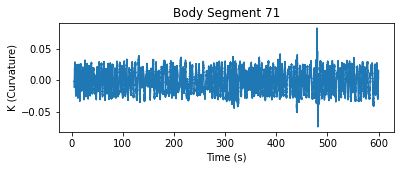

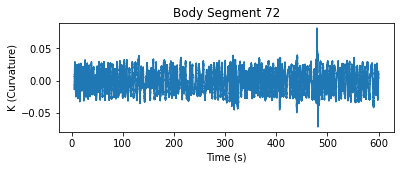

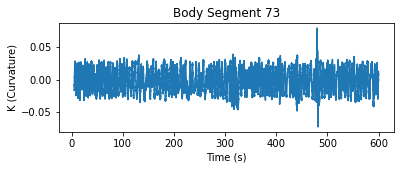

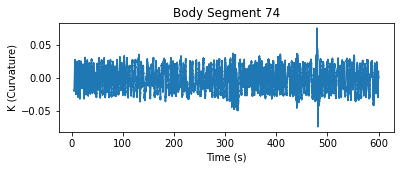

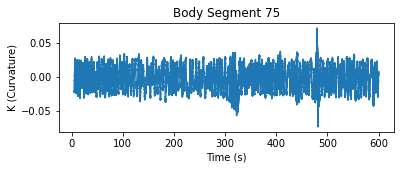

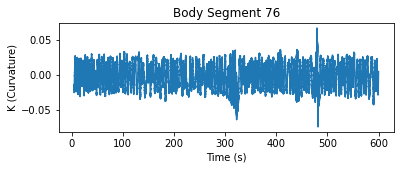

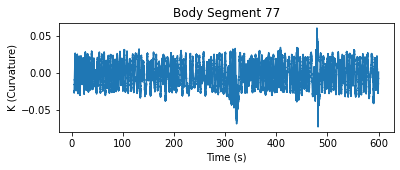

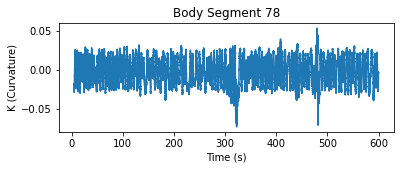

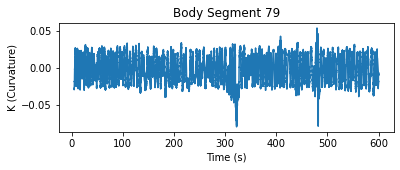

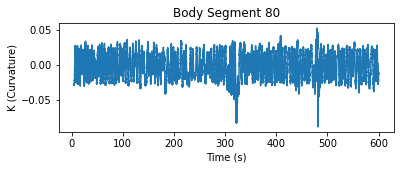

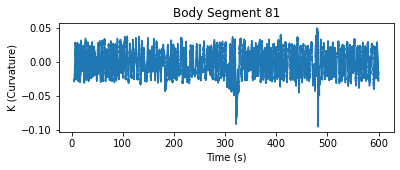

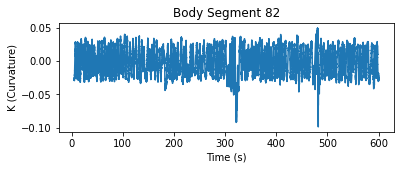

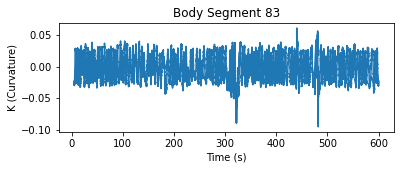

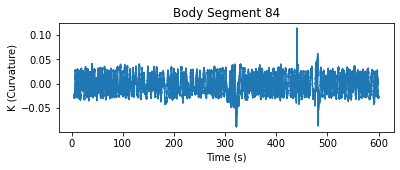

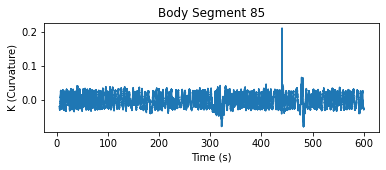

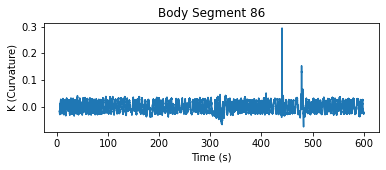

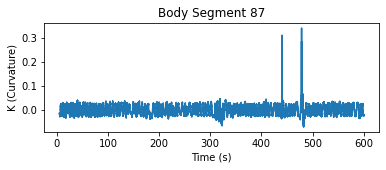

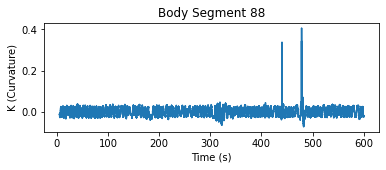

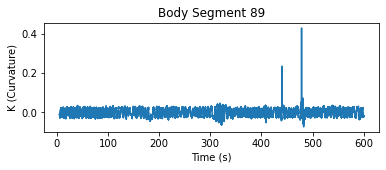

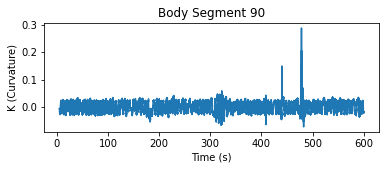

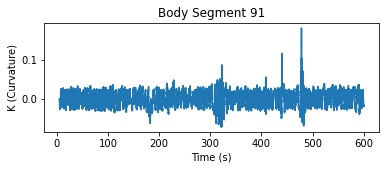

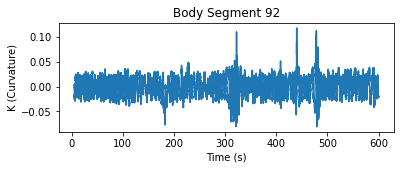

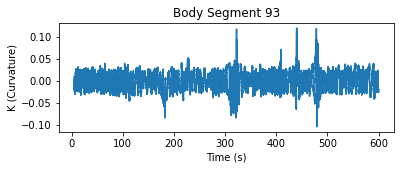

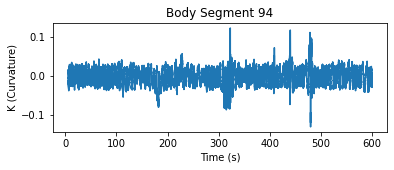

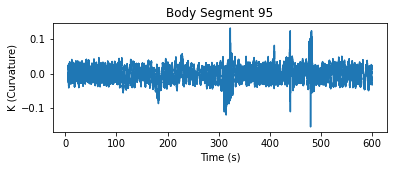

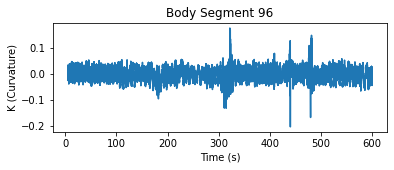

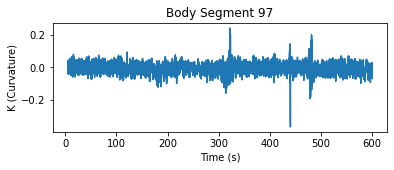

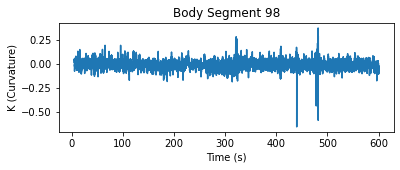

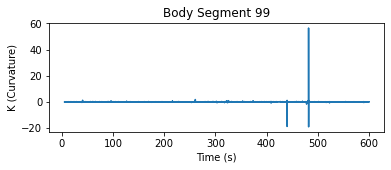

In [12]:
Kt=K.T

#define plot and axis
start=5
stop=600
fps=167
x_axis=np.linspace(start,stop,num=(stop-start)*fps)

for idx, segment in enumerate(Kt):
    #define which body segments to show
    #if idx%10!=0: continue
    fig=plt.figure(figsize=(6,2))
    plt.plot(x_axis,segment[start*fps:stop*fps])
    plt.title('Body Segment '+str(idx))
    plt.xlabel('Time (s)')
    plt.ylabel('K (Curvature)')
    plt.show()
#    break

(0.0, 3.0)

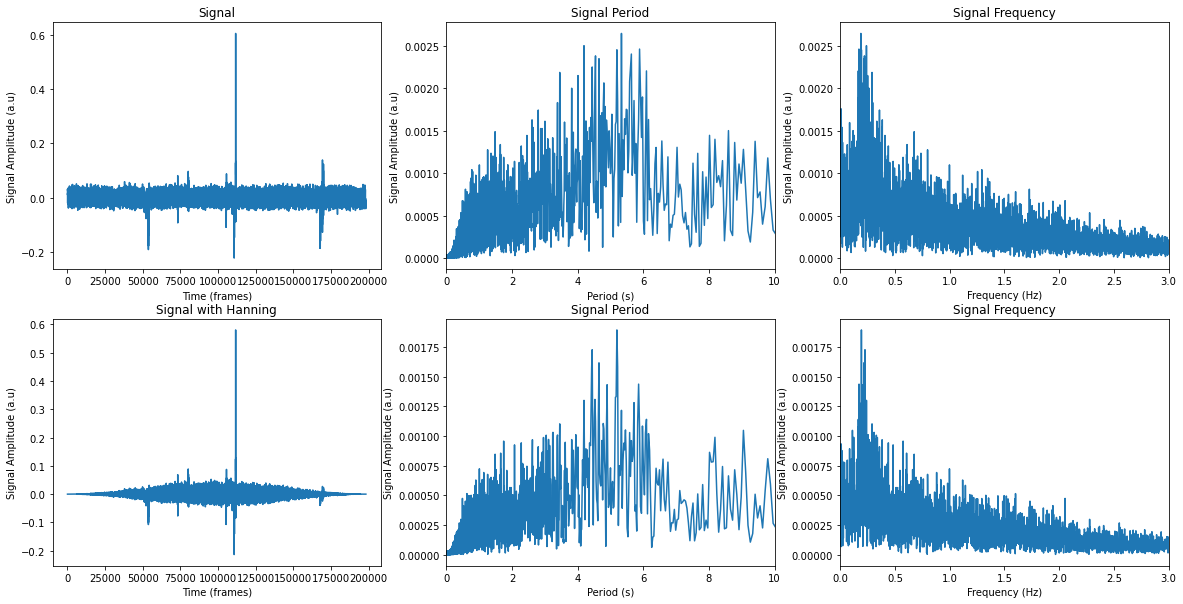

In [10]:
#number of sample points with Hanning
body_segment=5
y=K[:,body_segment]
N=len(y) #this might be wrong

#sample spacing
T=1.0/167.0
x=np.linspace(0.0, N*T, N)
yf=scipy.fftpack.fft(y)

xf=np.linspace(0.0, 1.0//(2.0*T), N//2)
#xf=scipy.fftpack.fftfreq(N,T)
#define axes
#y_axis (see that it should start at 1 in yf[1:N//2])
y_axis=2.0/N * np.abs(yf[1:N//2])
#x_axis
x_axis=xf[1:N//2]

#with hanning
hann=np.hanning(N)
yf_hann=scipy.fftpack.fft(y*hann)
y_axis_hann=2.0/N * np.abs(yf_hann[1:N//2])


#Trying for the first time this way of subplotting
fig1, f1_axs = plt.subplots(ncols=3, nrows=2, constrained_layout=False, figsize=(20,10))
f1_axs[0,0].plot(y)
f1_axs[0,0].set_title('Signal')
f1_axs[0,0].set_xlabel('Time (frames)')
f1_axs[0,0].set_ylabel('Signal Amplitude (a.u)')

f1_axs[0,1].plot(1/x_axis, y_axis)
f1_axs[0,1].set_title('Signal Period')
f1_axs[0,1].set_xlabel('Period (s)')
f1_axs[0,1].set_ylabel('Signal Amplitude (a.u)')
f1_axs[0,1].set_xlim(0,10)

f1_axs[0,2].plot(x_axis, y_axis)
f1_axs[0,2].set_title('Signal Frequency')
f1_axs[0,2].set_xlabel('Frequency (Hz)')
f1_axs[0,2].set_ylabel('Signal Amplitude (a.u)')
f1_axs[0,2].set_xlim(0,3)

#hanning plotting
f1_axs[1,0].plot(y*hann)
f1_axs[1,0].set_title('Signal with Hanning')
f1_axs[1,0].set_xlabel('Time (frames)')
f1_axs[1,0].set_ylabel('Signal Amplitude (a.u)')

f1_axs[1,1].plot(1/x_axis, y_axis_hann)
f1_axs[1,1].set_title('Signal Period')
f1_axs[1,1].set_xlabel('Period (s)')
f1_axs[1,1].set_ylabel('Signal Amplitude (a.u)')
f1_axs[1,1].set_xlim(0,10)

f1_axs[1,2].plot(x_axis, y_axis_hann)
f1_axs[1,2].set_title('Signal Frequency')
f1_axs[1,2].set_xlabel('Frequency (Hz)')
f1_axs[1,2].set_ylabel('Signal Amplitude (a.u)')
f1_axs[1,2].set_xlim(0,3)

### Comparison of x axis
Here I wanted to see how the axis of y_axis compare if one does not plot xf as ax axis.

Might need to readjust it if one changes the parameters of the code above

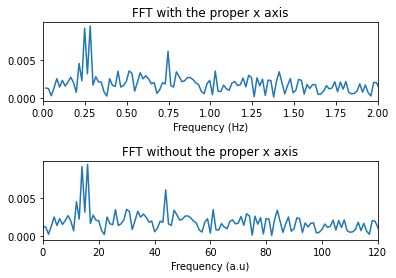

In [117]:
plt.subplot(2,1,1)
plt.plot(xf[1:N//2], 2.0/N * np.abs(yf[1:N//2]))
plt.xlim(0,2)
plt.xlabel('Frequency (Hz)')
plt.title('FFT with the proper x axis')
plt.subplot(2,1,2)
plt.plot((2.0/N * np.abs(yf[1:N//2]))[0:500])
#this has to be manually adjusted
plt.xlim(0,120)
plt.title('FFT without the proper x axis')
plt.xlabel('Frequency (a.u)')
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.75)
plt.show()

### FFT For the whole splineK and save it an image

In [3]:
#load data
#csv_filepath='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-07-01_14-41-11_chemotaxisl_worm2_spline_K.csv'
csv_filepath='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-07-01_10-50-18_control_worm2_spline_K.csv'
K = np.genfromtxt(csv_filepath, delimiter=',')
#to remove nan rows in the data
K=K[~np.isnan(K).any(axis=1)]
Kt=K.T

In [10]:
#new skeletons
import matplotlib
font = {'family' : 'Sans Serif',
        'weight' : 'normal',
        'size'   : 6}

matplotlib.rc('font', **font)

In [4]:
%matplotlib inline

In [5]:

main_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/skeleton_after_head_and_tail_from_unet_all/'

files=glob.glob(os.path.join(main_path,'*2020-07-01_13-21-00_chemotaxisl_worm1*spline_K*'))
csv_filepath=files[0]
csv_filepath

'/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/skeleton_after_head_and_tail_from_unet_all/2020-07-01_13-21-00_chemotaxisl_worm1-_spline_K.csv'

In [8]:
K = np.genfromtxt(csv_filepath, delimiter=',')
#if you wnat to to remove nan rows in the data (important for PCA)
#K=K[~np.isnan(K).any(axis=1)]

Kt=K.T

0


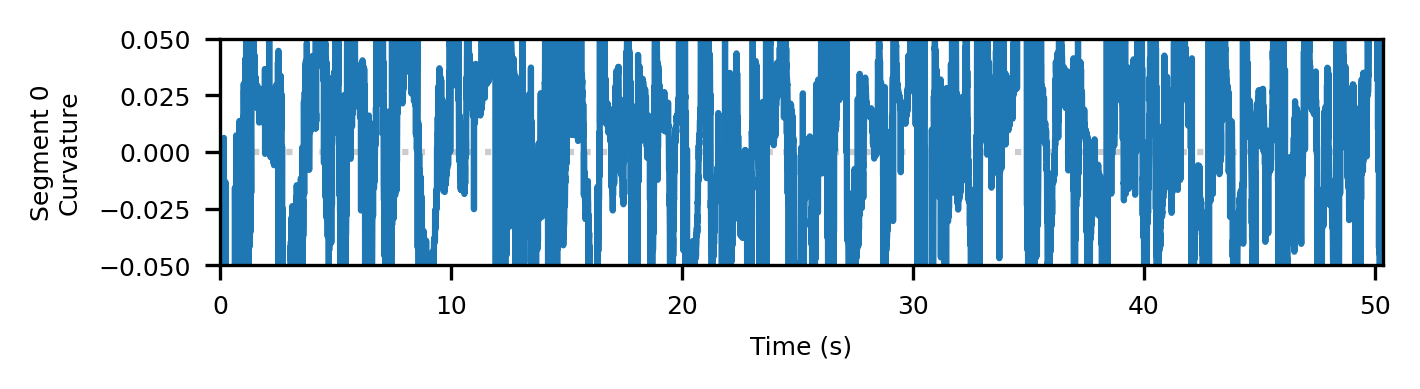

1
2
3
4
5


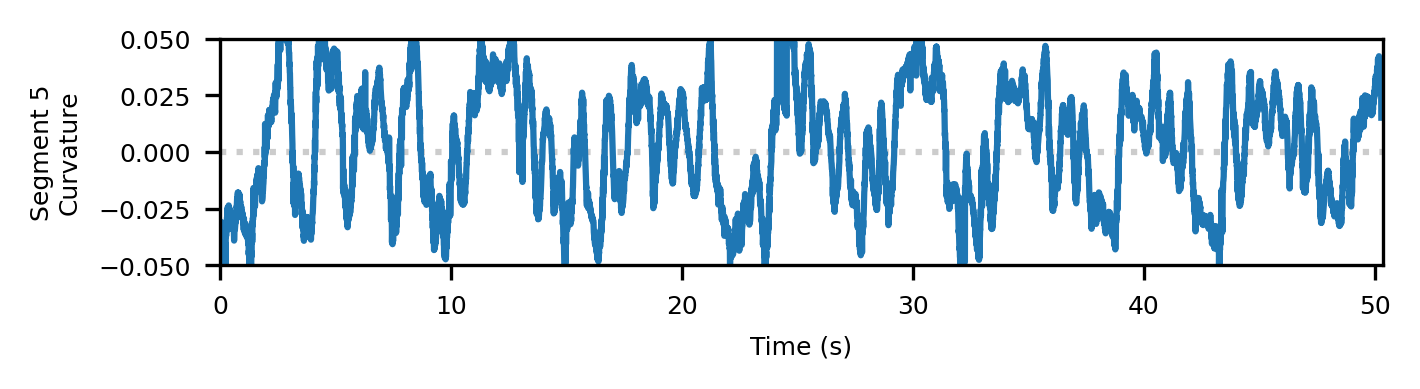

6
7
8
9
10


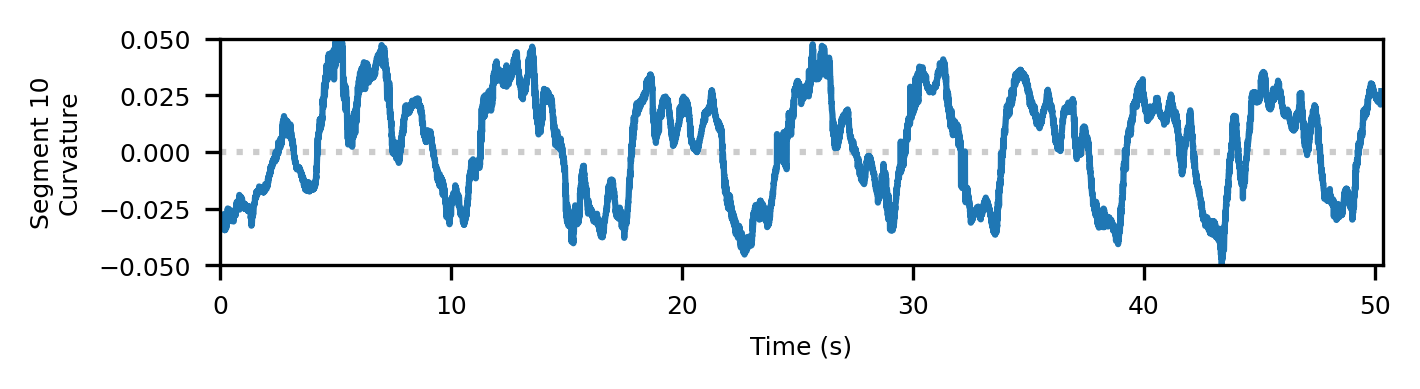

11
12
13
14
15


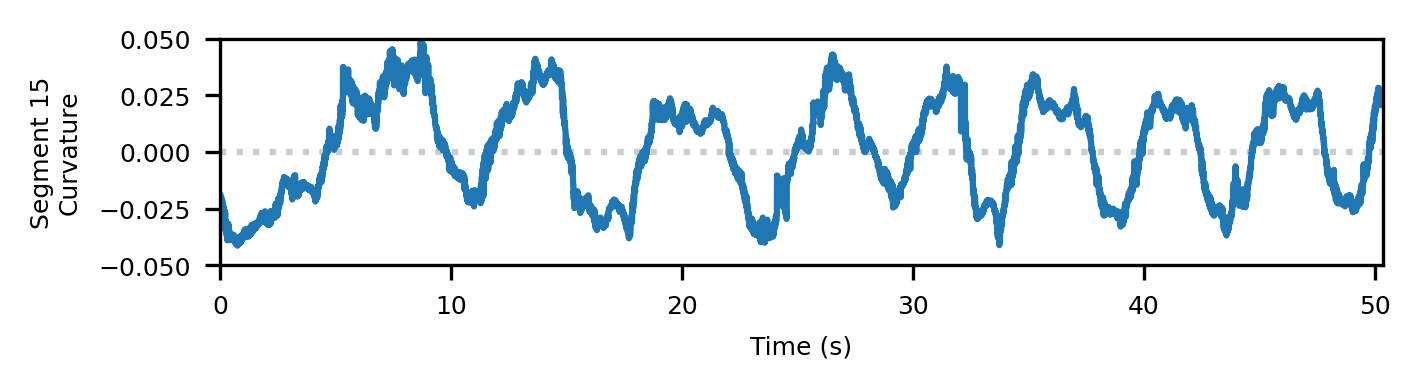

16
17
18
19
20


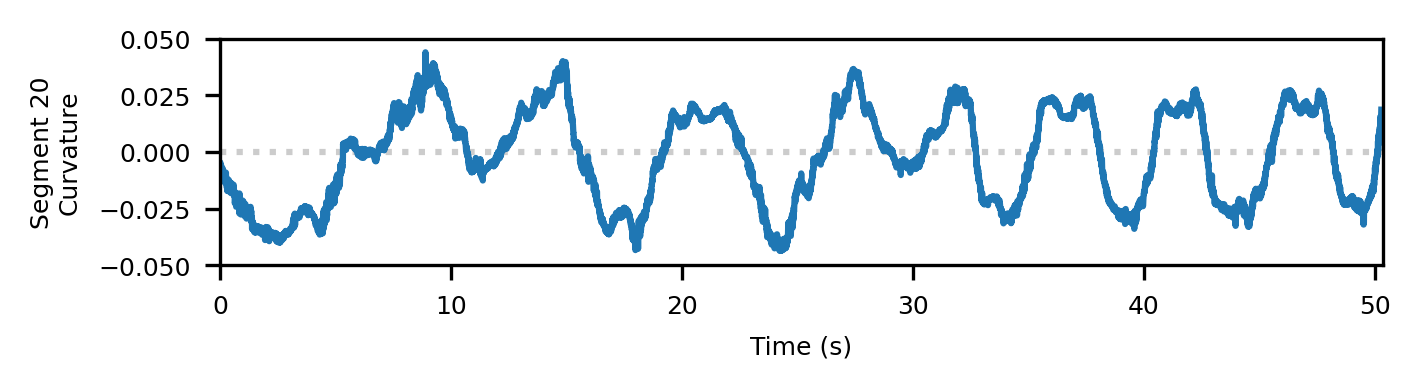

21
22
23
24
25


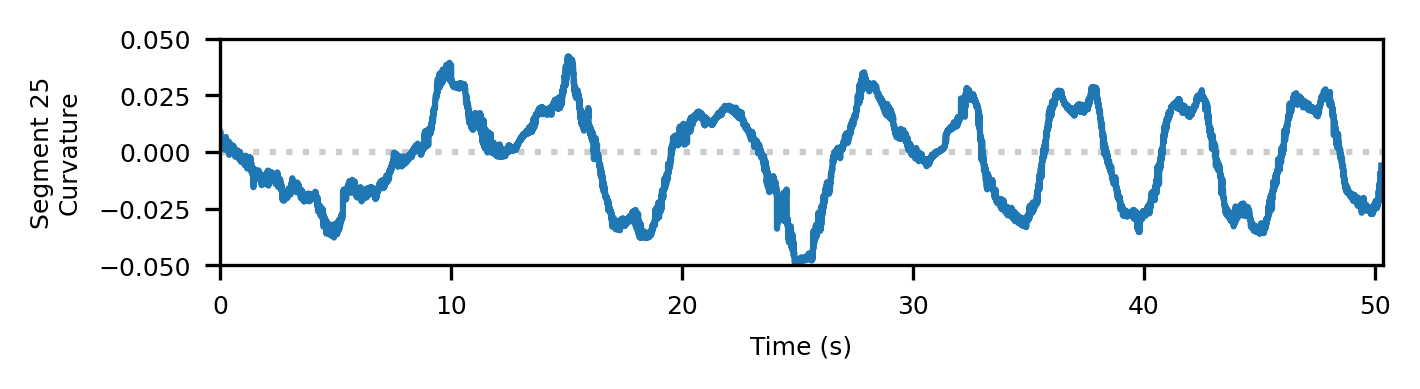

26
27
28
29
30


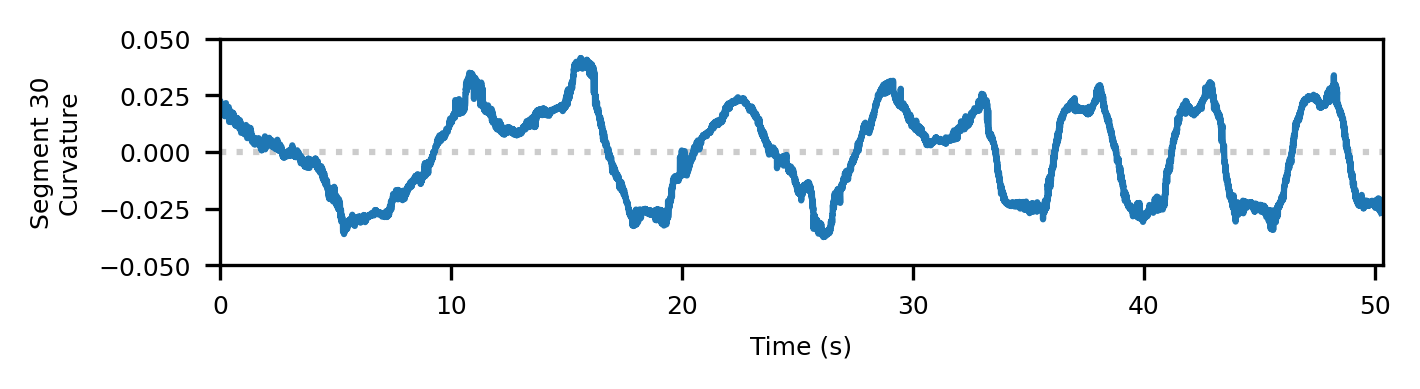

31
32
33
34
35


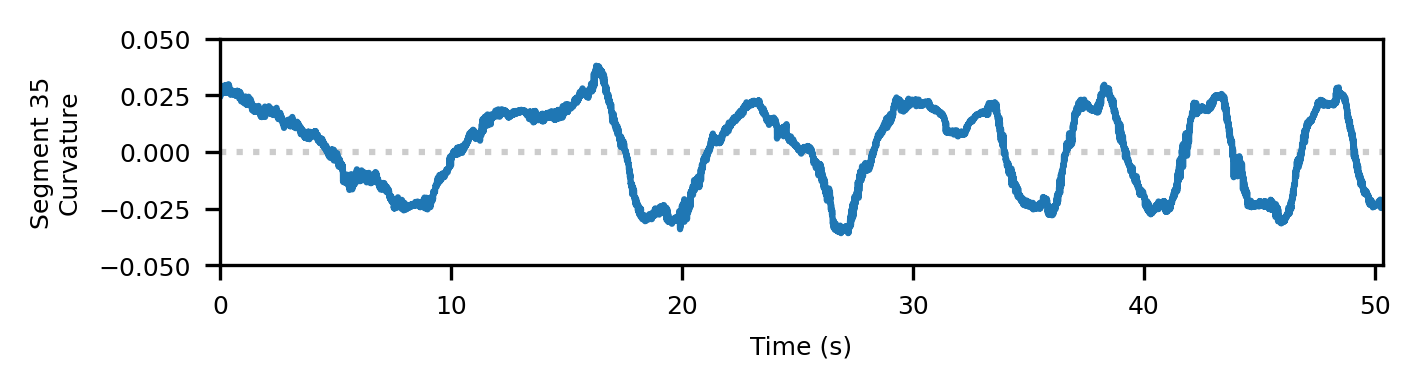

36
37
38
39
40


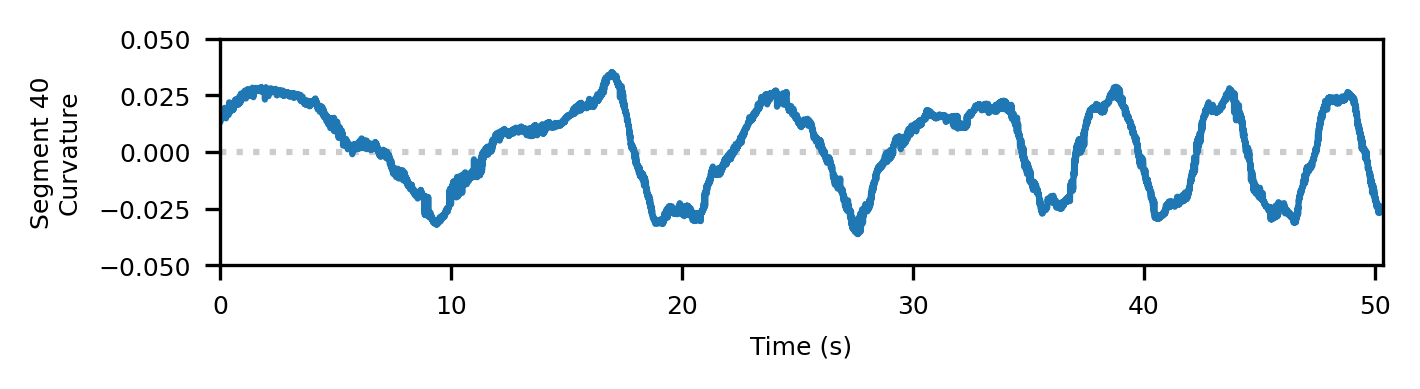

41
42
43
44
45


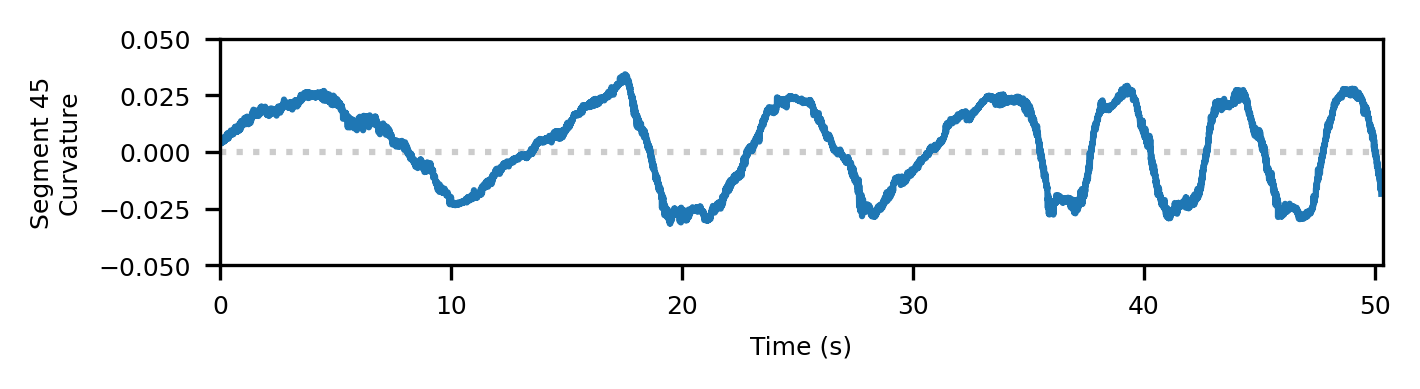

46
47
48
49
50


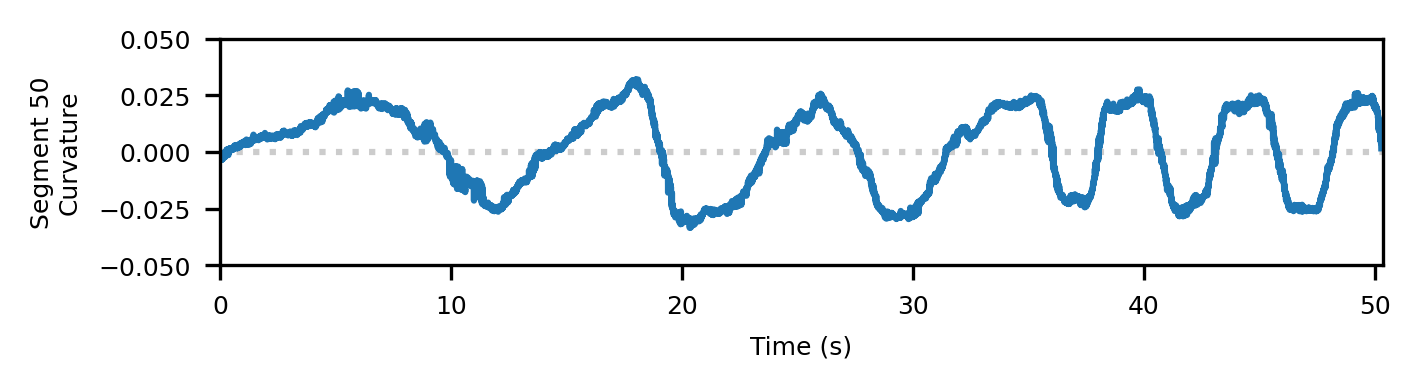

51
52
53
54
55


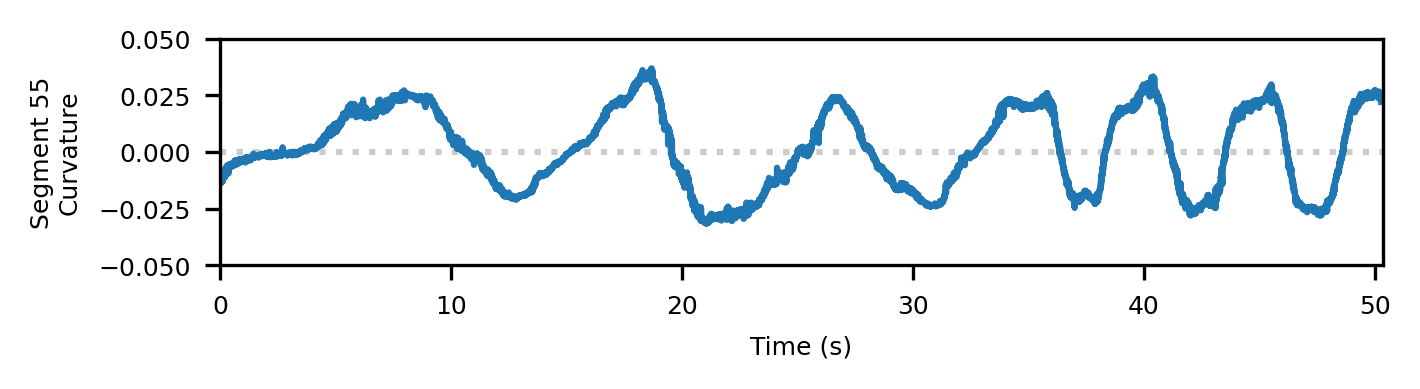

56
57
58
59
60


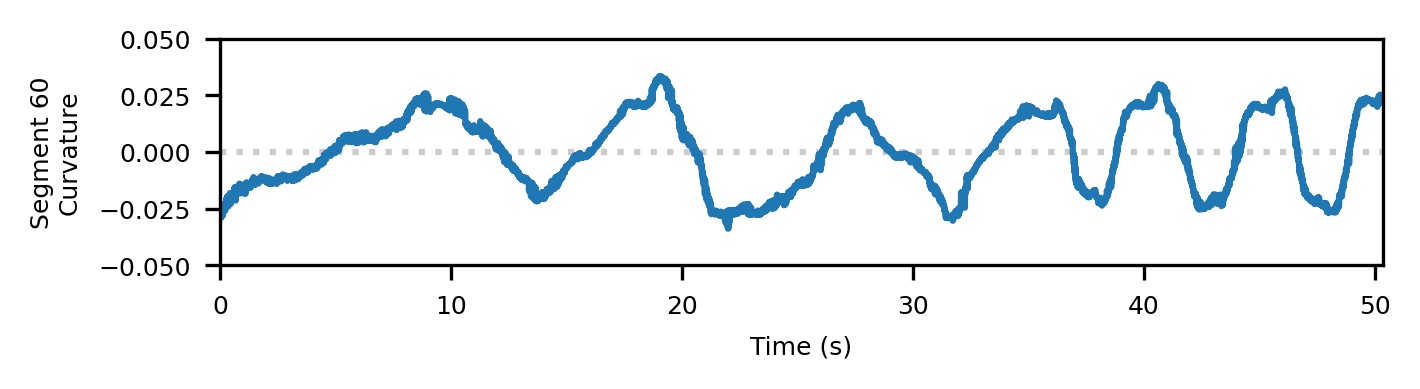

61
62
63
64
65


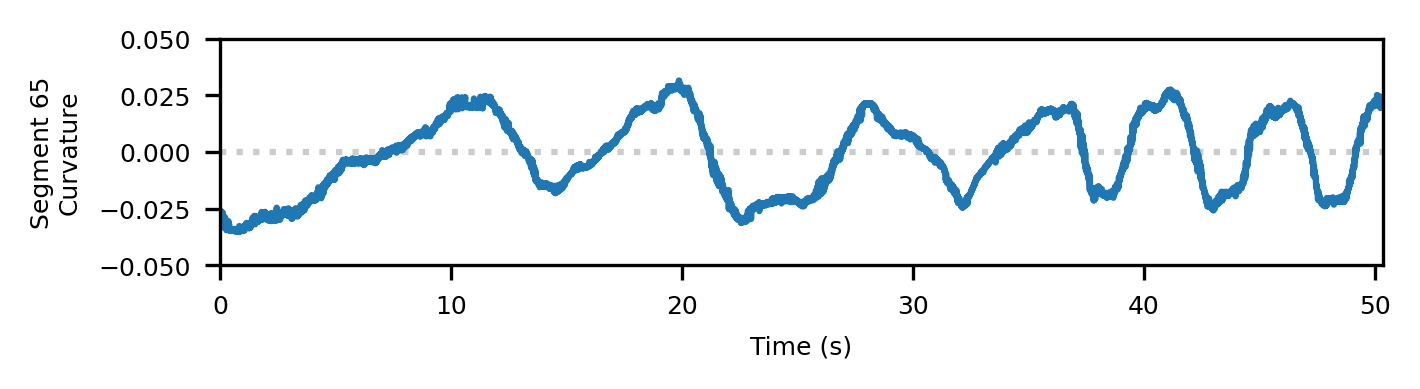

66
67
68
69
70


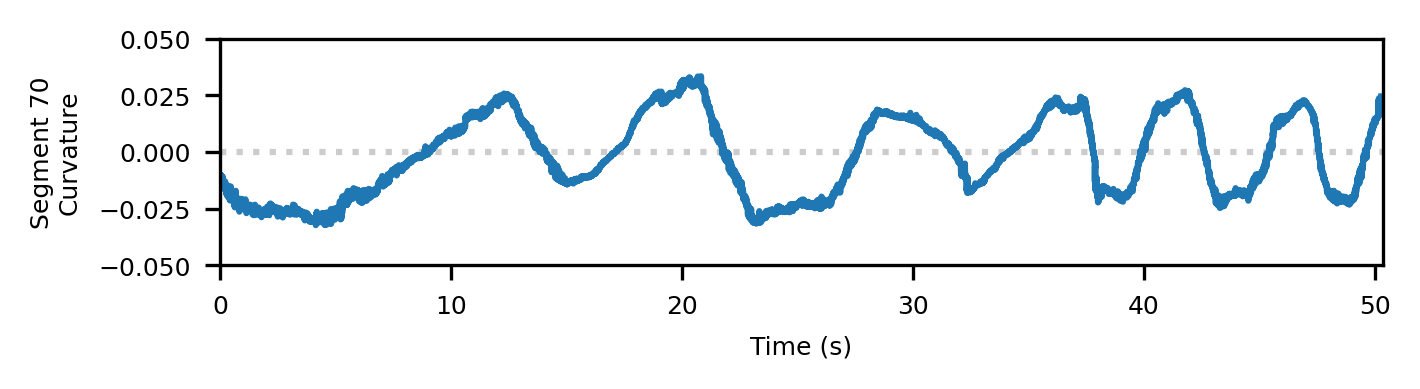

71
72
73
74
75


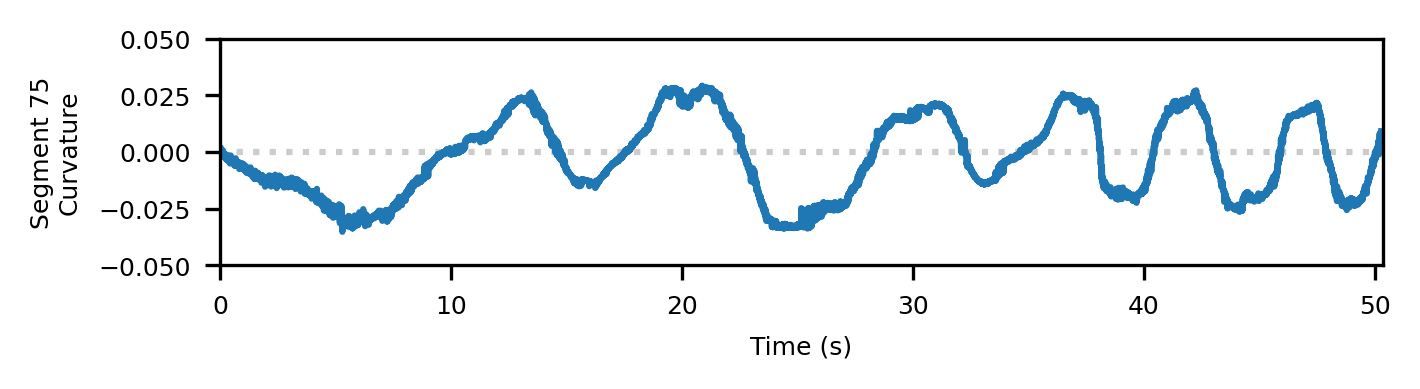

76
77
78
79
80


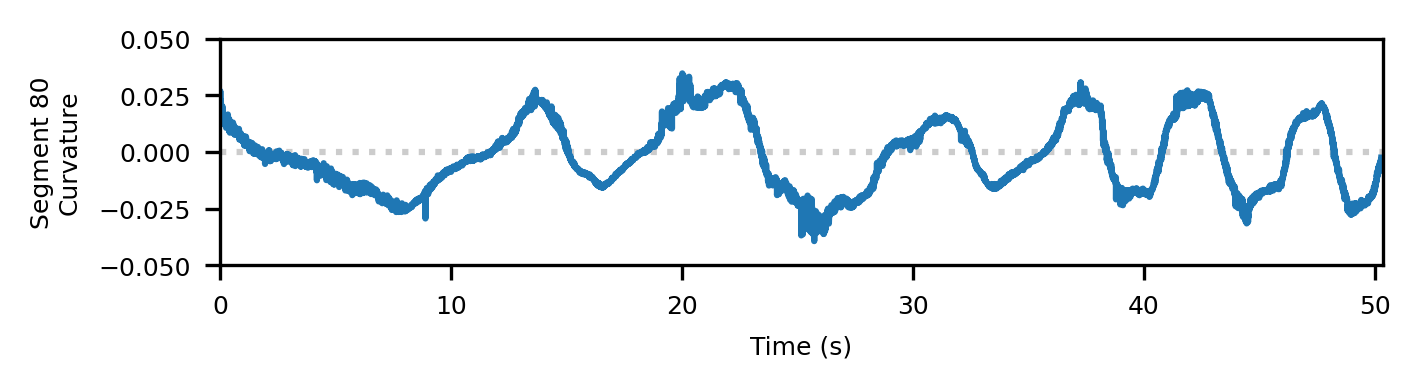

81
82
83
84
85


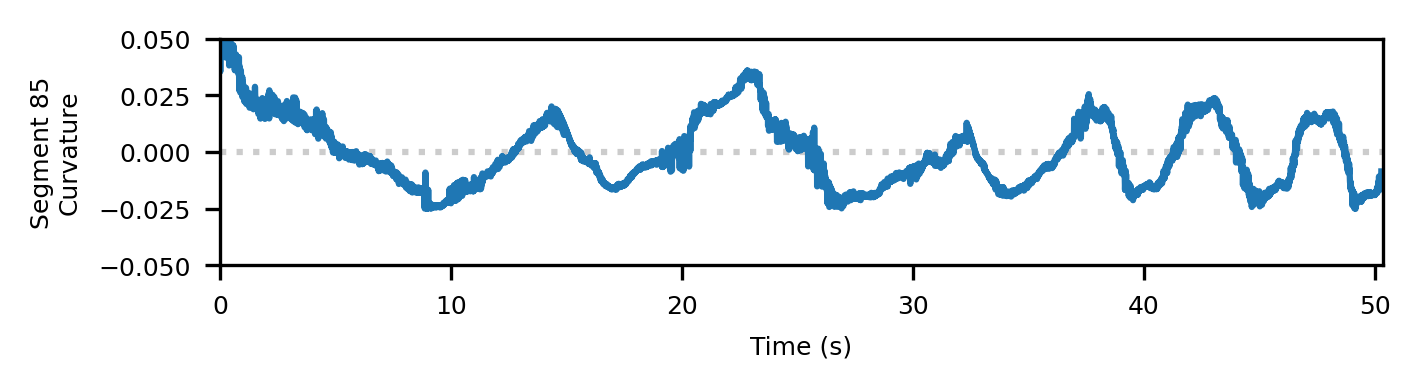

86
87
88
89
90


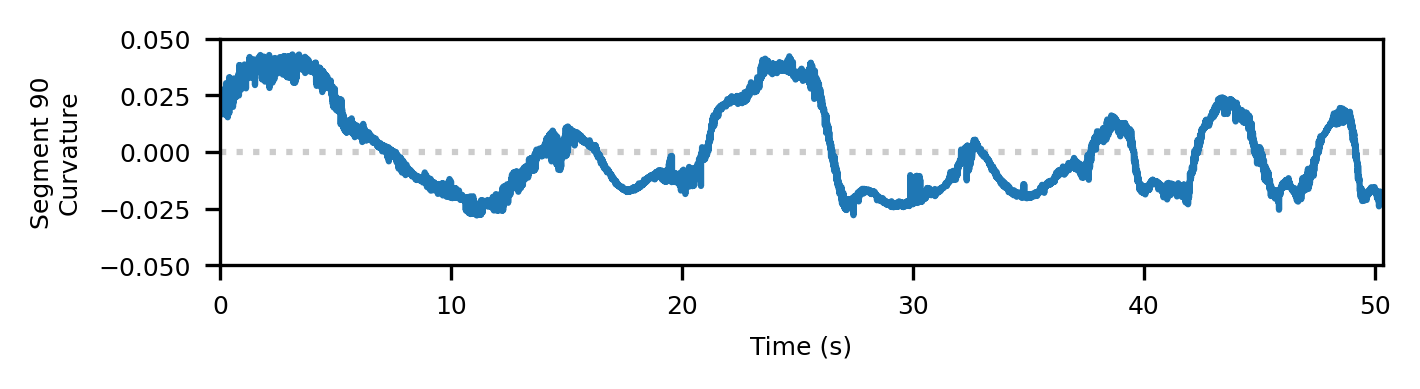

91
92
93
94
95


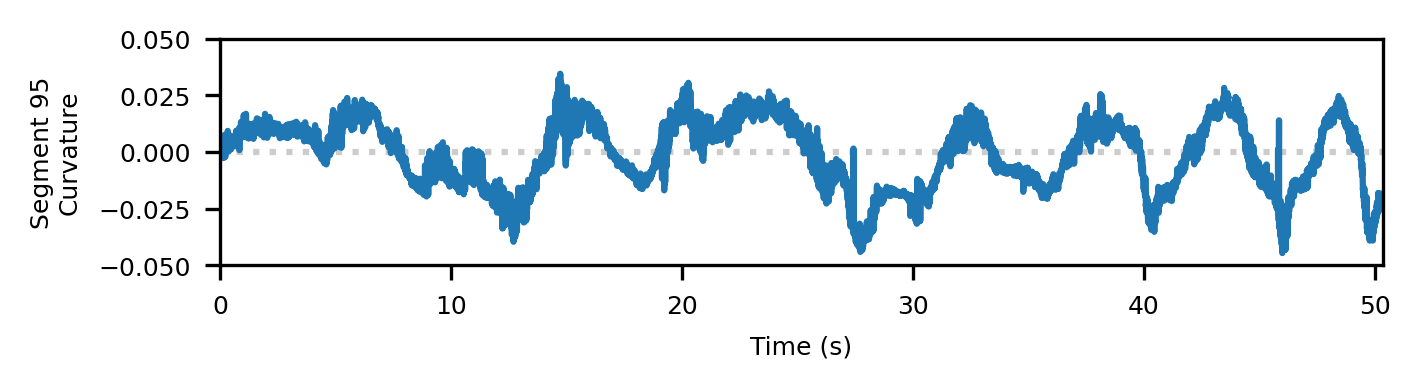

96
97
98
99


In [17]:
#plot only curvature (maybe not needed)
#to not to have a figure limit
plt.rcParams.update({'figure.max_open_warning': 0})

#number of sample points: Kts= Kt short
t0=105600#0
tf=114000#500

Kts=Kt[:,t0:tf]#[:,0:2500]#[:,0:2500]#[:,79640:130700]

time=np.arange(0, Kts[0].shape[0]/167,1/167)

N=Kts.shape[1]
for idx, segment in enumerate(Kts):
    print(idx)
    #time=np.arange(0, segment.shape[0]/167,1/167)
    #skip some segments
    if idx%10!=5 and idx%10!=0:continue
    fig,ax=plt.subplots(dpi=300,figsize=(5,1))
    ax.plot(time,segment)
    #ax.set_xticks(np.linspace(t0,tf,11))
    #ax.set_xticklabels(np.arange(0,51,5))
    ax.set_xlim([0, 50.35])
    ax.set_ylim([-0.05, 0.05])
    #ax.set_title('Segment '+str(idx))
    plt.hlines(0, 0, 50.35, colors='k', linestyles='dotted', label='', data=None, alpha=.2)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Segment '+str(idx)+'\nCurvature')
    plt.show()


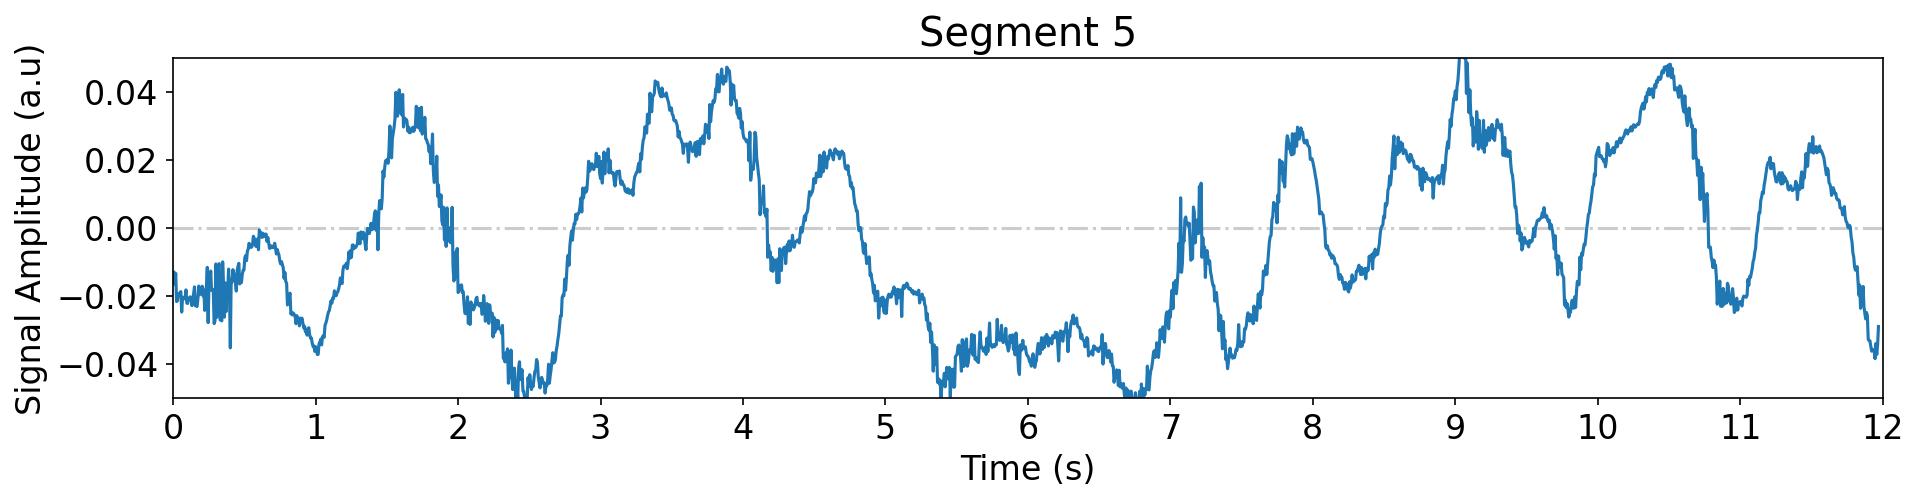

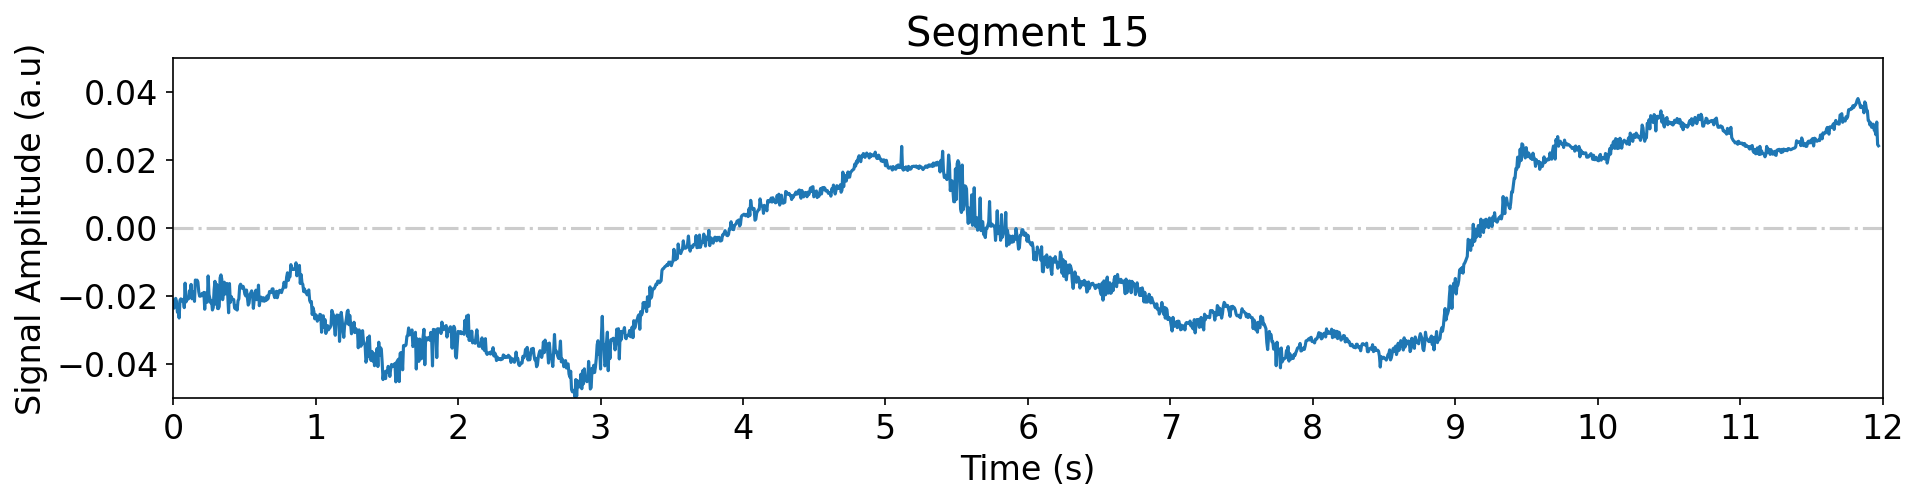

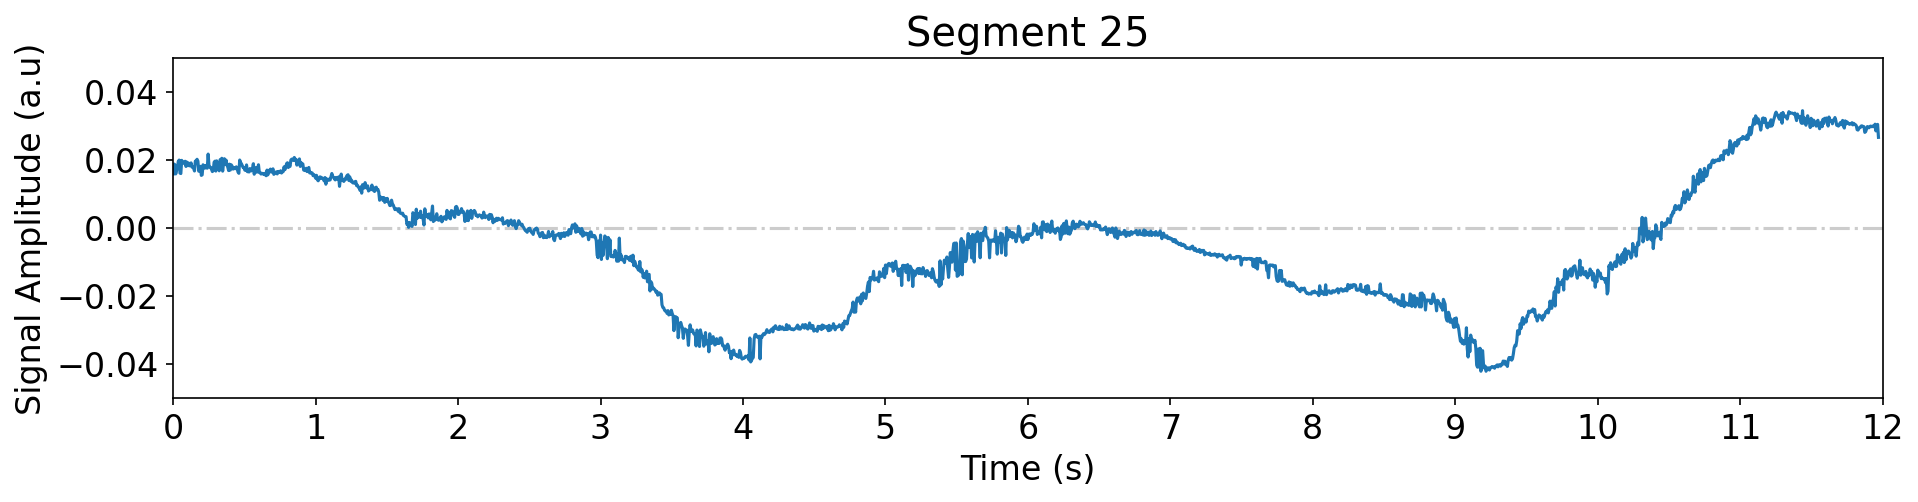

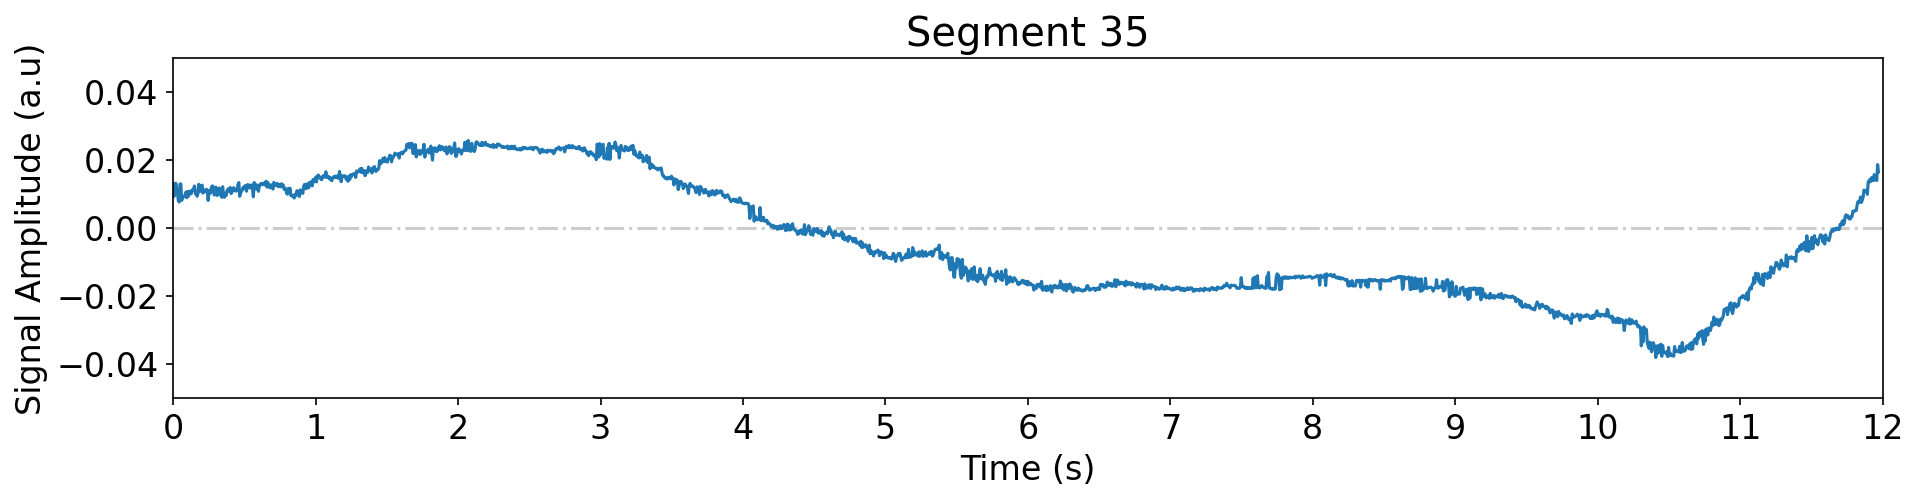

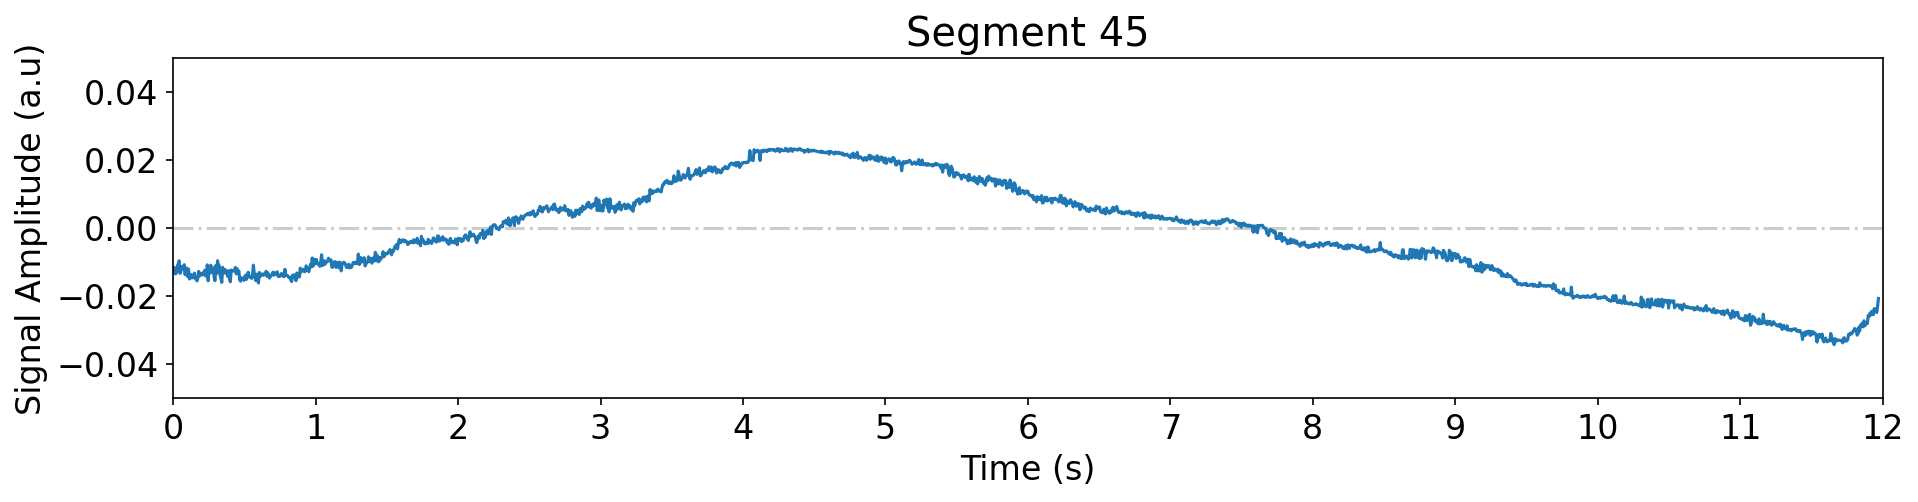

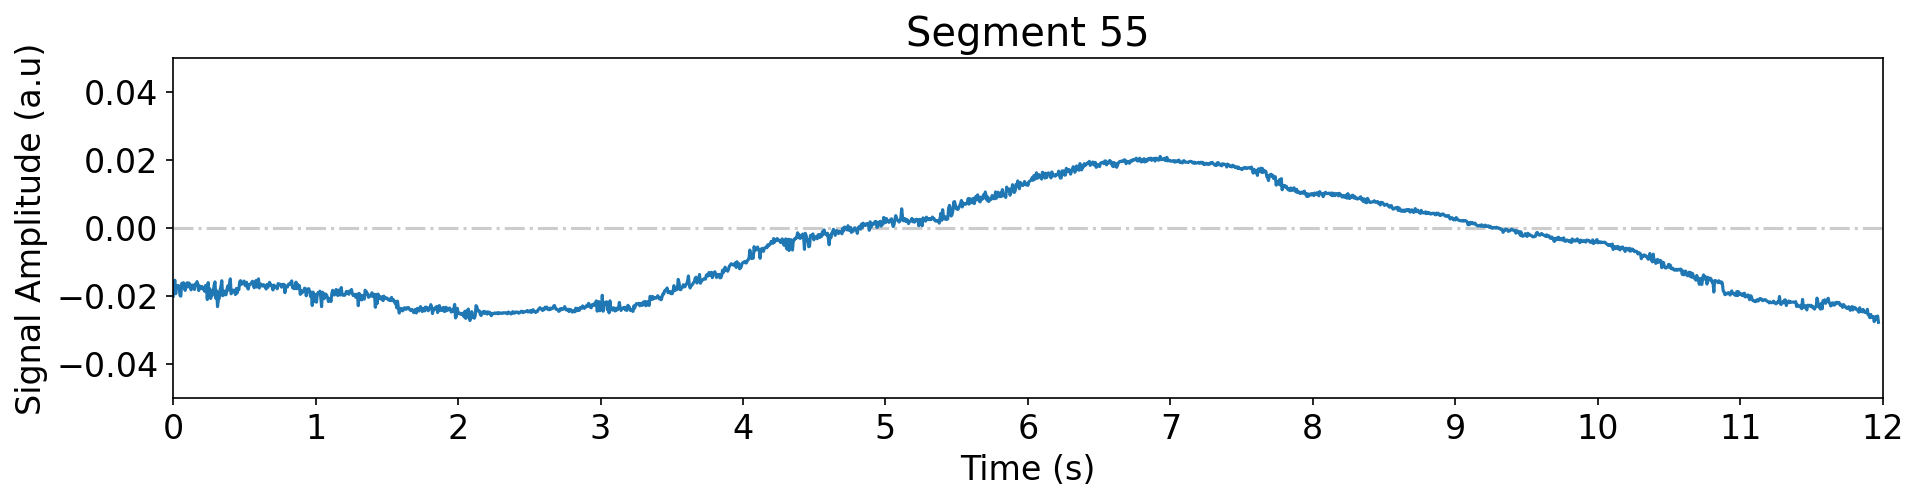

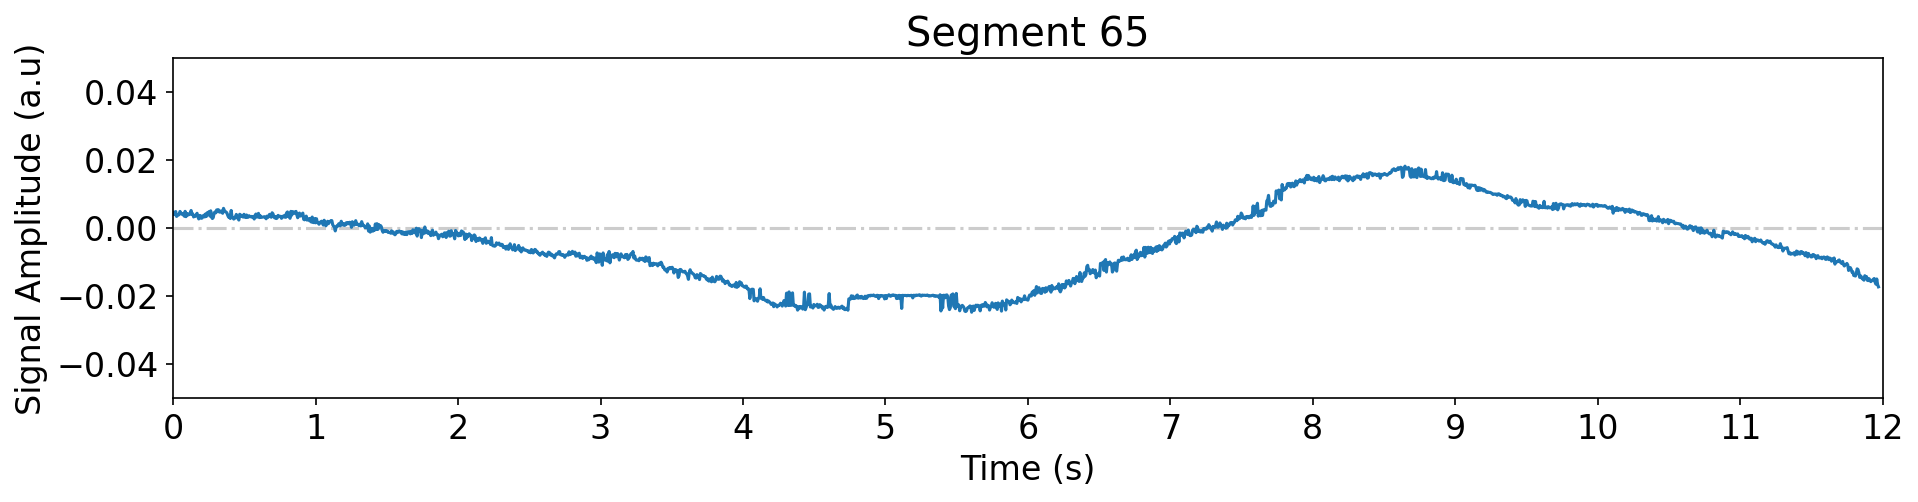

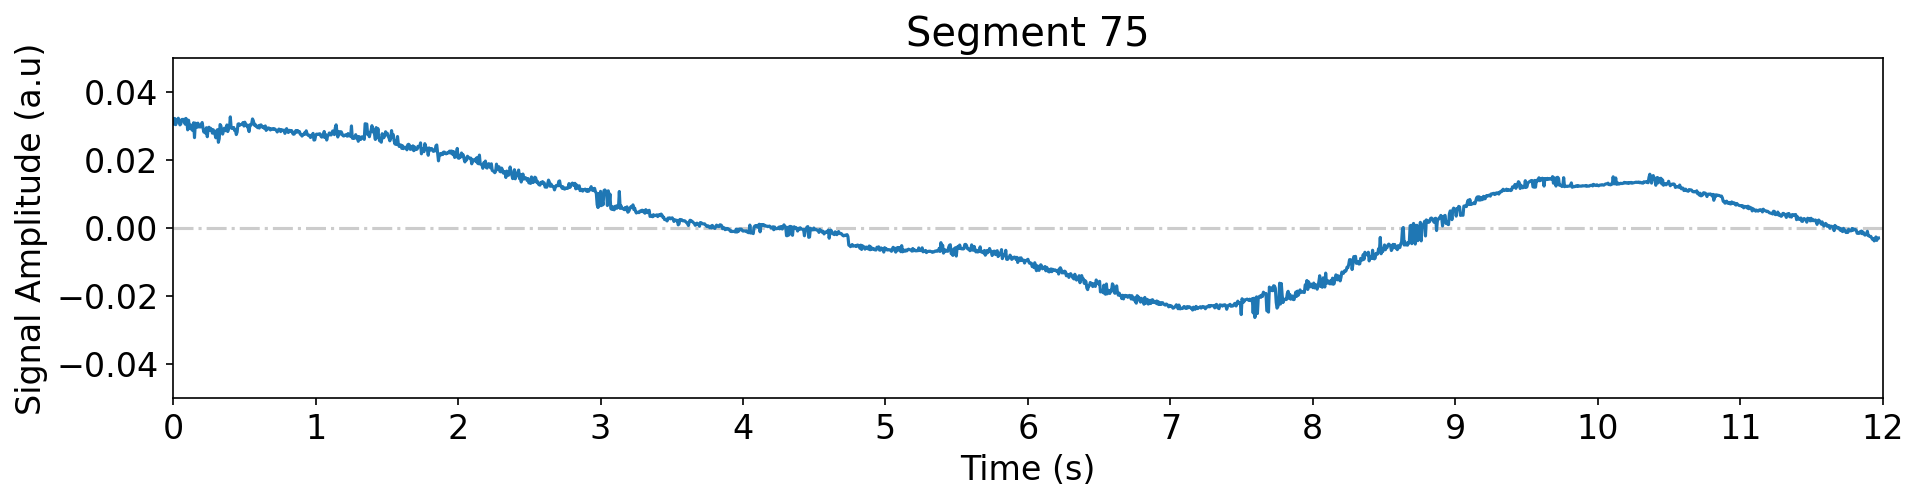

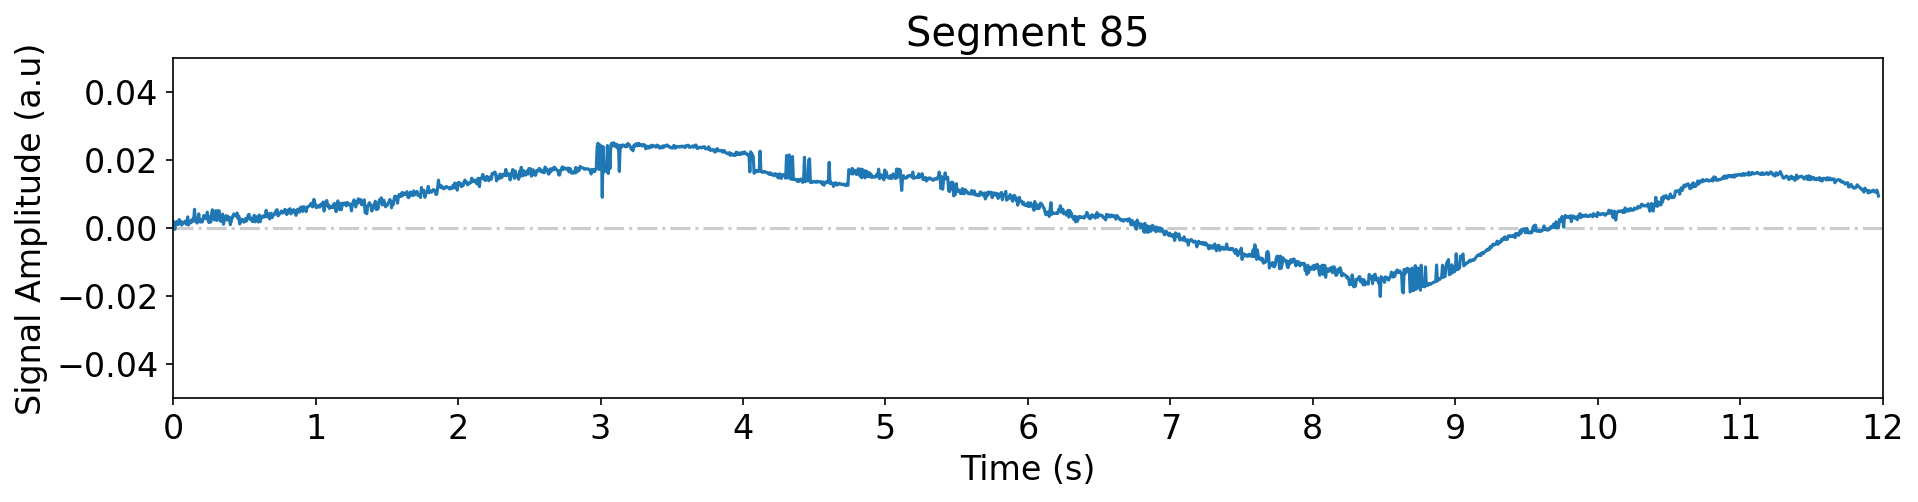

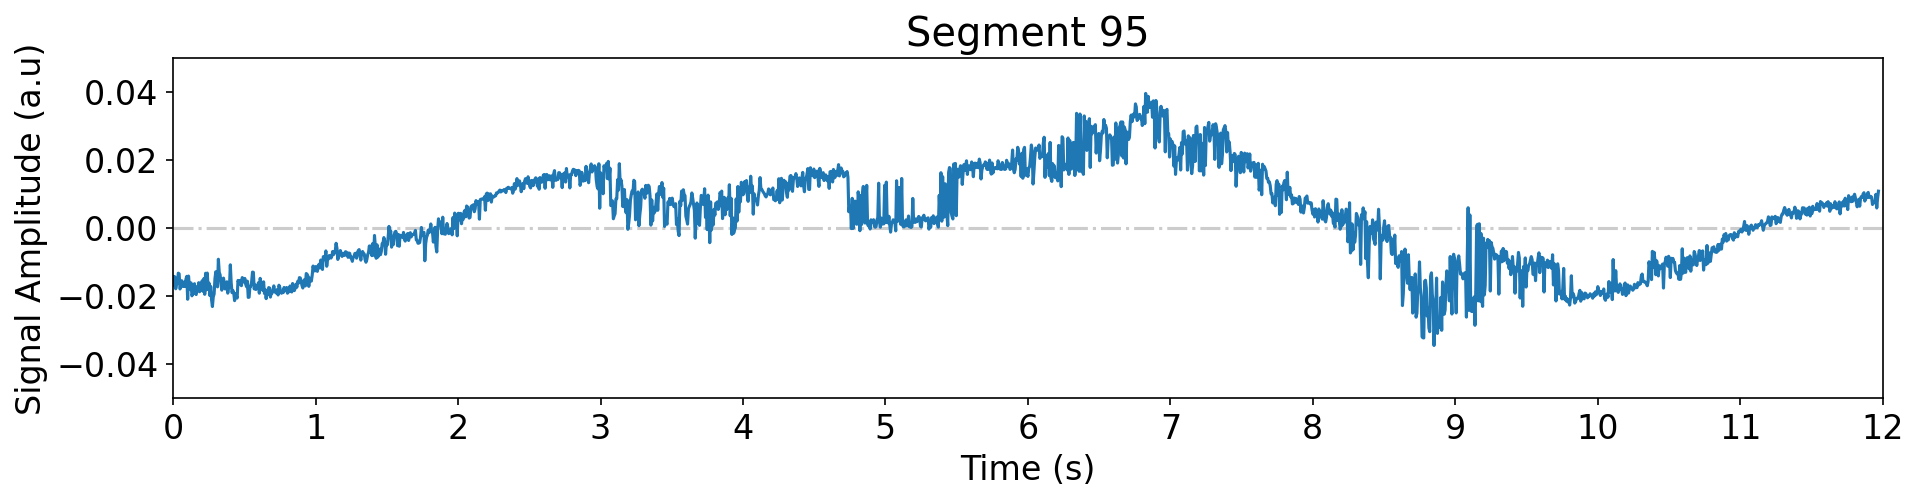

In [76]:
#plot only curvature (maybe not needed)
#to not to have a figure limit
plt.rcParams.update({'figure.max_open_warning': 0})
plt.rcParams.update({'font.size': 16})

#number of sample points: Kts= Kt short
Kts=Kt[:,105600:114000]#[:,0:2500]#[:,0:2500]#[:,79640:130700]

N=Kts.shape[1]

#hanning
hann=np.hanning(N)

#sample spacing
T=1.0/167.0
x=np.linspace(0.0, N*T, N)

xf=np.linspace(0.0, 1.0//(2.0*T), N//2)
#xf=scipy.fftpack.fftfreq(N,T)

#creates the writer
output_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_fourier/'
fourierMap=open(os.path.join(output_path,'2020-07-01_14-41-11_chemotaxisl_worm2_fourierMap.csv'),'w', newline='')
csv_writerfourierMap=csv.writer(fourierMap)

for idx, segment in enumerate(Kts):
    #skip some segments
    if idx%10!=5:continue
    
    y=segment
    yf=scipy.fftpack.fft(y)#*hann)
    #define axes
    #y_axis (see that it should start at 1 in yf[1:N//2])
    y_axis=2.0/N * np.abs(yf[1:N//2])
    #x_axis
    x_axis=xf[1:N//2]
    #writer:
    
    #csv_writerfourierMap.writerow(2.0/N * np.abs(yf[1:N//2]))
    
    #define x and y
    x=np.arange(0, y[400:2400].shape[0]/167,1/167)
    y=y[400:2400]
    
    #plotting:
    plotting=1
    if plotting==0:continue
    plt.figure(dpi=150,figsize=(50,3))
    plt.subplot(1,3,1)
    plt.plot(x,-1*y)
    plt.ylim([-0.05, 0.05])
    plt.xlim([0, 12])
    plt.xticks(np.linspace(0, 12,13))
    plt.title('Segment '+str(idx))
    plt.hlines(0, 0, 12, colors='k', linestyles='dashdot', label='', data=None, alpha=.2)
    plt.xlabel('Time (s)')
    plt.ylabel('Signal Amplitude (a.u)')


#fourierMap.close()

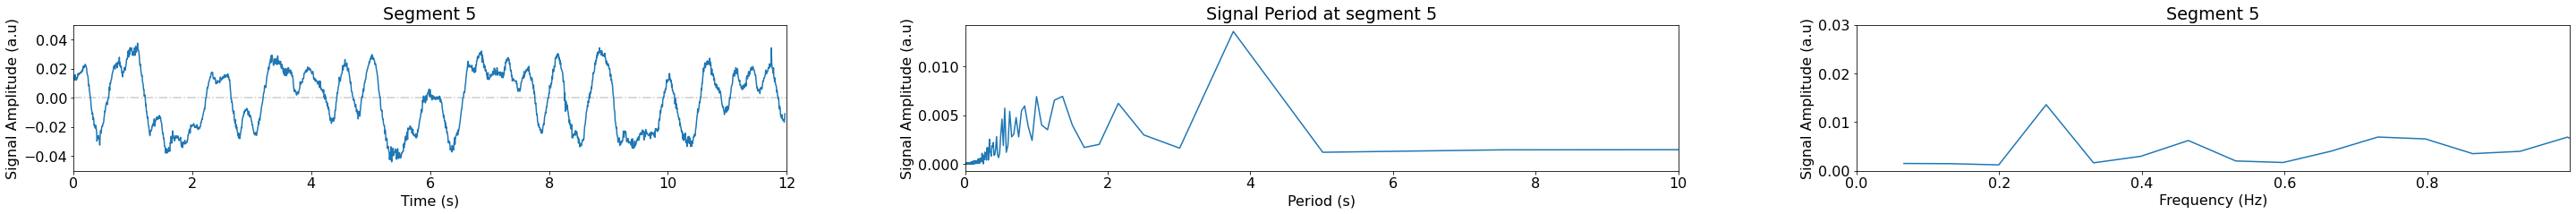

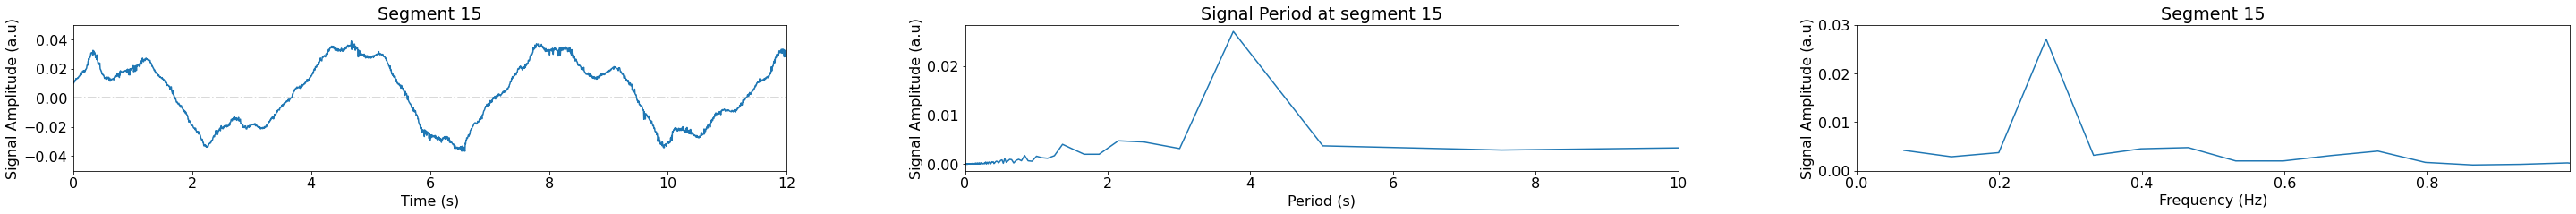

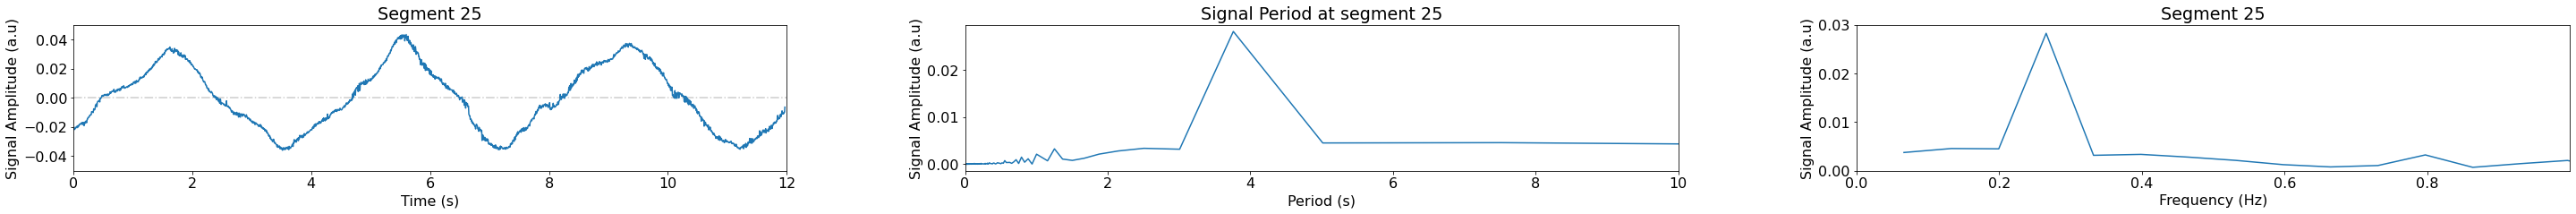

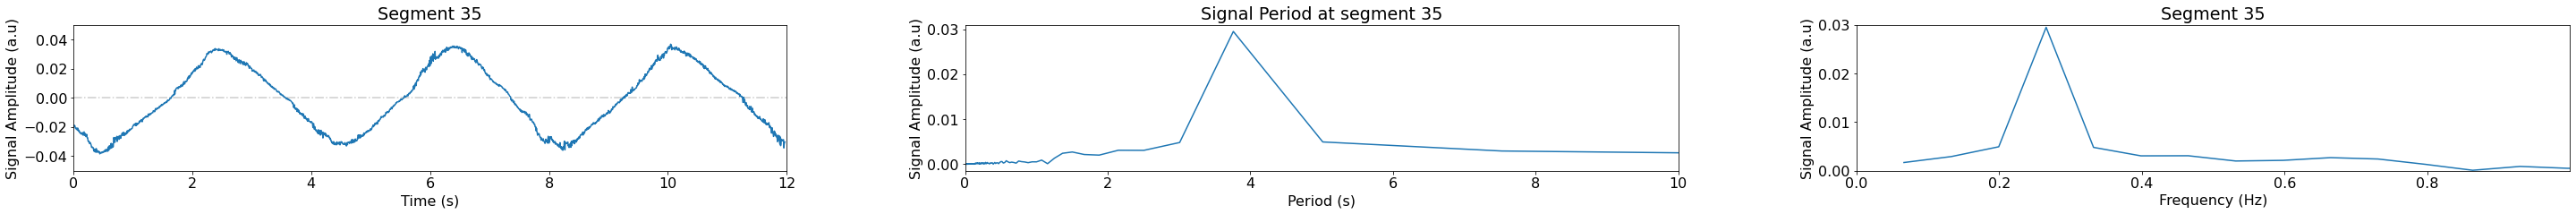

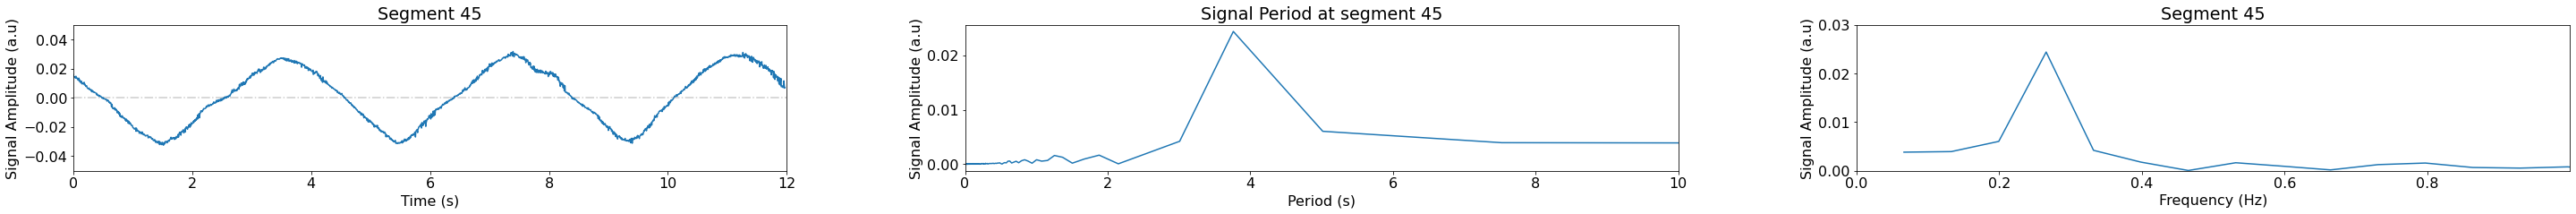

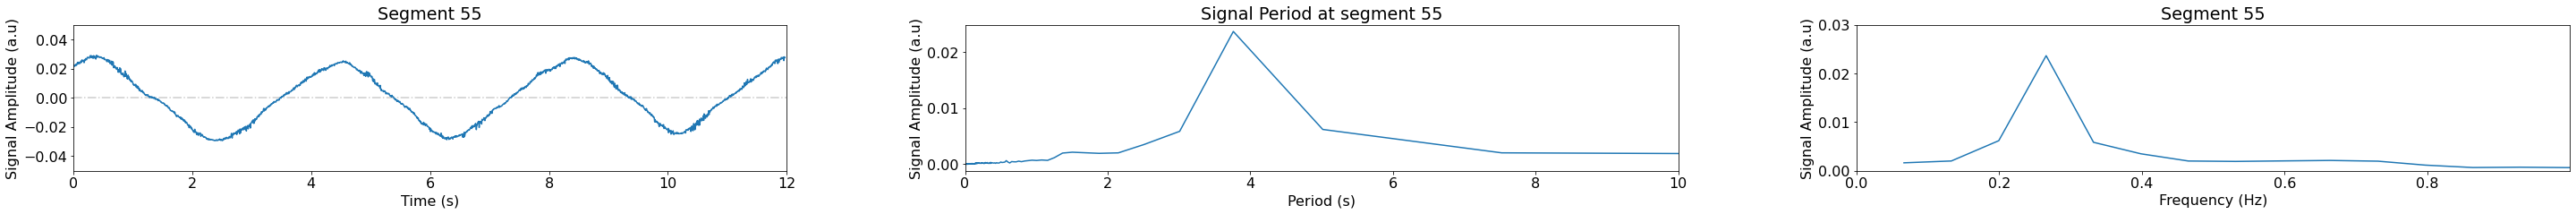

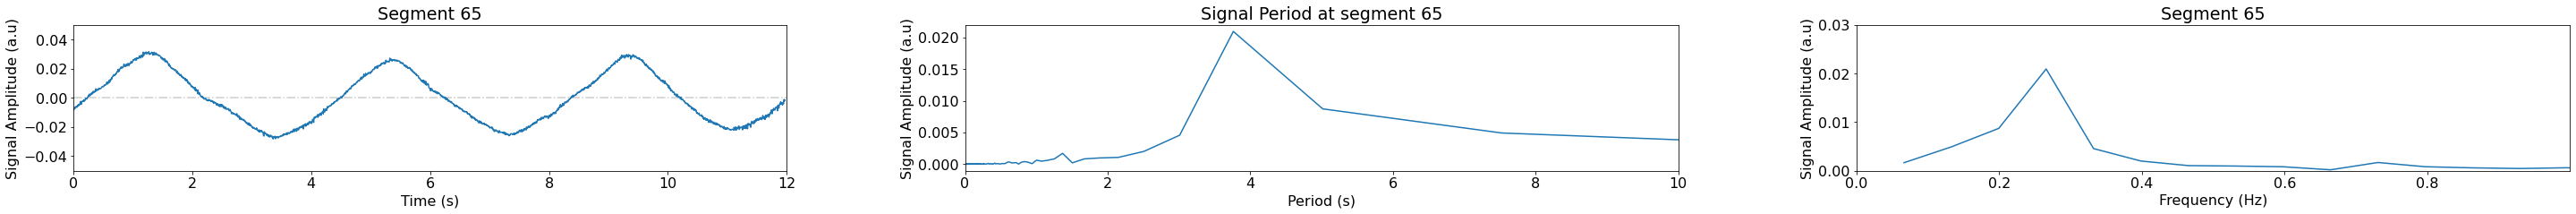

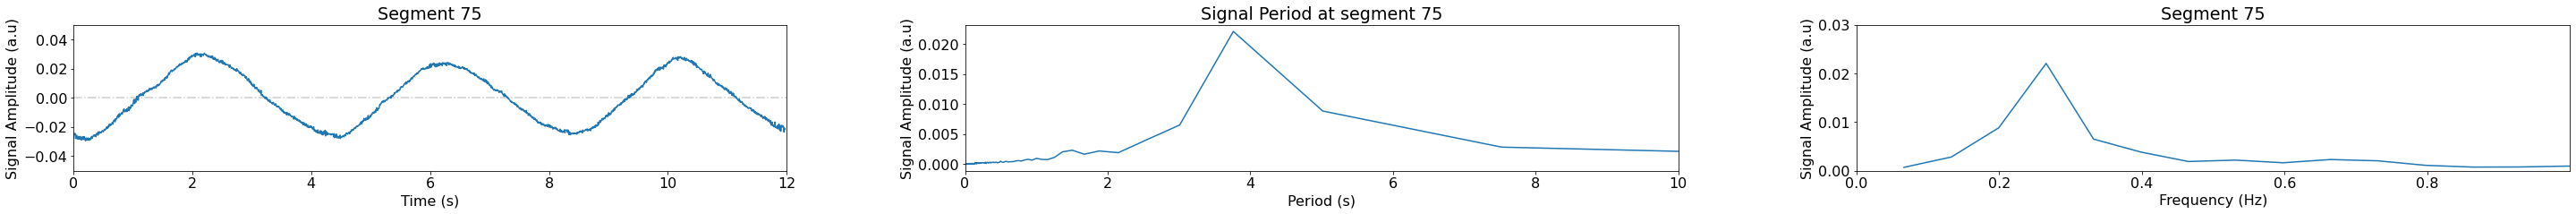

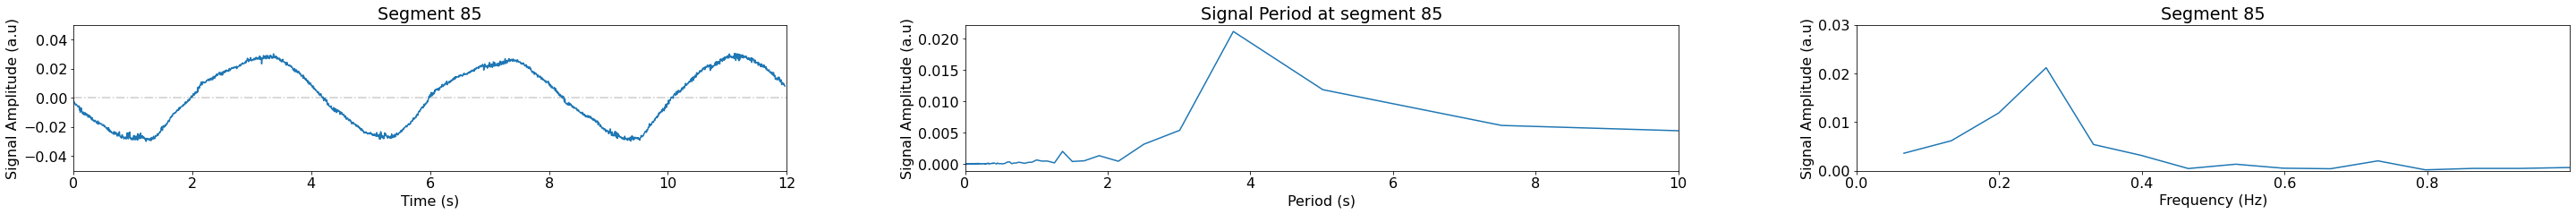

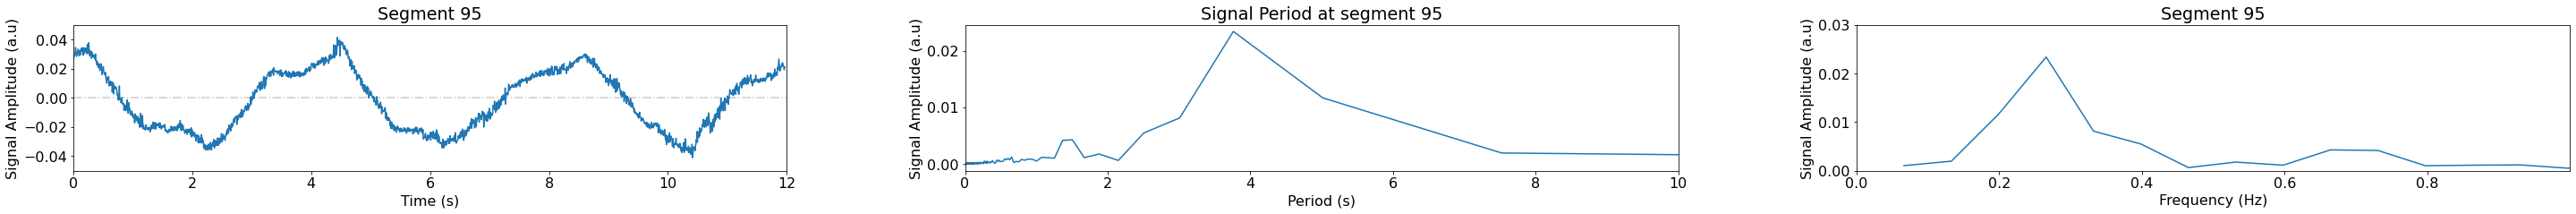

In [18]:
#to not to have a figure limit
plt.rcParams.update({'figure.max_open_warning': 0})
plt.rcParams.update({'font.size': 16})

#number of sample points: Kts= Kt short
Kts=Kt[:,0:2500]#[:,0:2500]#[:,79640:130700]

N=Kts.shape[1]

#hanning
hann=np.hanning(N)

#sample spacing
T=1.0/167.0
x=np.linspace(0.0, N*T, N)

xf=np.linspace(0.0, 1.0//(2.0*T), N//2)
#xf=scipy.fftpack.fftfreq(N,T)

#creates the writer
output_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_fourier/'
fourierMap=open(os.path.join(output_path,'2020-07-01_14-41-11_chemotaxisl_worm2_fourierMap.csv'),'w', newline='')
csv_writerfourierMap=csv.writer(fourierMap)

for idx, segment in enumerate(Kts):
    #skip some segments
    if idx%10!=5:continue
    
    y=segment
    yf=scipy.fftpack.fft(y)#*hann)
    #define axes
    #y_axis (see that it should start at 1 in yf[1:N//2])
    y_axis=2.0/N * np.abs(yf[1:N//2])
    #x_axis
    x_axis=xf[1:N//2]
    #writer:
    
    #csv_writerfourierMap.writerow(2.0/N * np.abs(yf[1:N//2]))
    
    #define x and y
    x=np.arange(0, y[400:2400].shape[0]/167,1/167)
    y=y[400:2400]
    
    #plotting:
    plotting=1
    if plotting==0:continue
    plt.figure(figsize=(50,3))
    plt.subplot(1,3,1)
    plt.plot(x,-1*y)
    plt.ylim([-0.05, 0.05])
    plt.xlim([0, 12])
    plt.title('Segment '+str(idx))
    plt.hlines(0, 0, 12, colors='k', linestyles='dashdot', label='', data=None, alpha=.2)
    plt.xlabel('Time (s)')
    plt.ylabel('Signal Amplitude (a.u)')
    
    #period (ignore)
    plt.subplot(1,3,2)
    plt.plot(1/x_axis, y_axis)
    plt.xlim(0,10)
    plt.title('Signal Period at segment '+str(idx))
    plt.xlabel('Period (s)')
    plt.ylabel('Signal Amplitude (a.u)')
    
    #Frequency
    plt.subplot(1,3,3)
    plt.plot(x_axis, y_axis)
    #plt.xlim(0,max(xf[1:N//2]))
    plt.xlim(0,1)
    plt.ylim([0, 0.03])
    plt.xticks(np.arange(0, 1, step=0.2))

    
    plt.title('Segment '+str(idx))
    plt.ylabel('Signal Amplitude (a.u)')
    plt.xlabel('Frequency (Hz)')

    
    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.25, hspace=0.25)

#fourierMap.close()

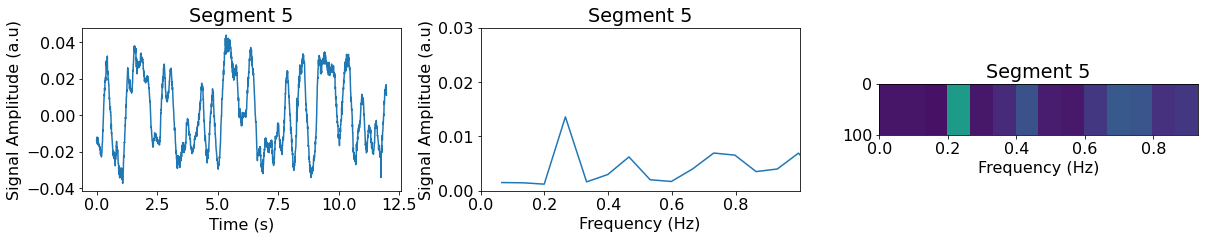

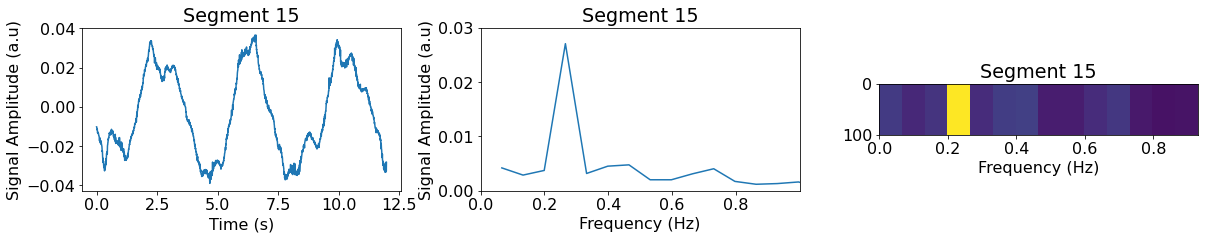

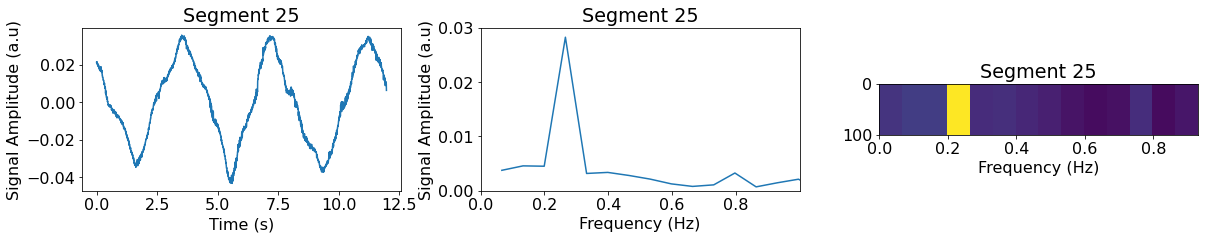

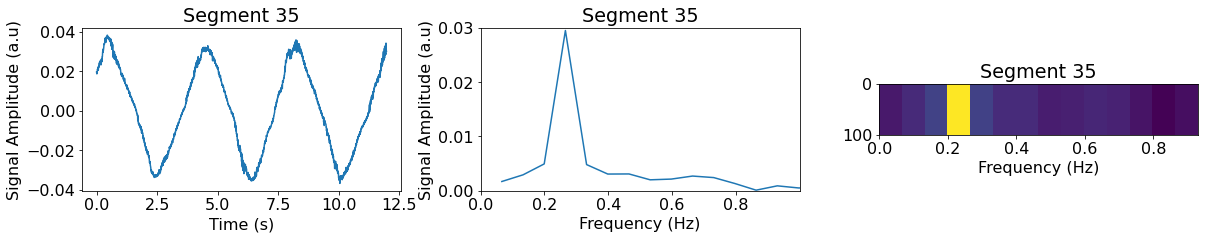

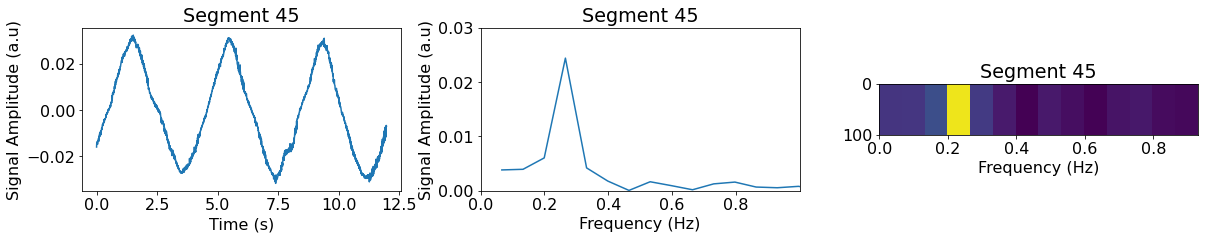

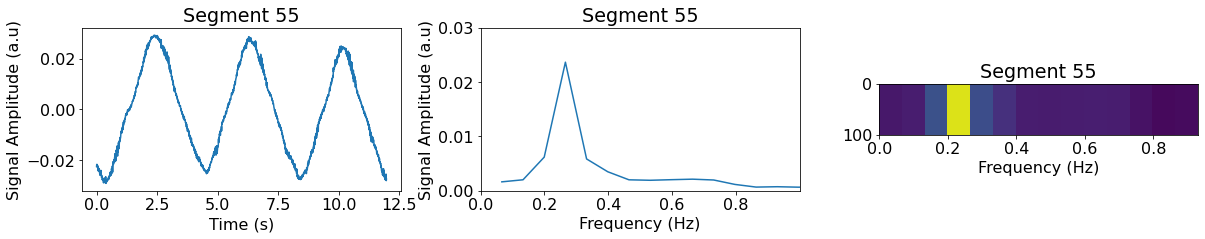

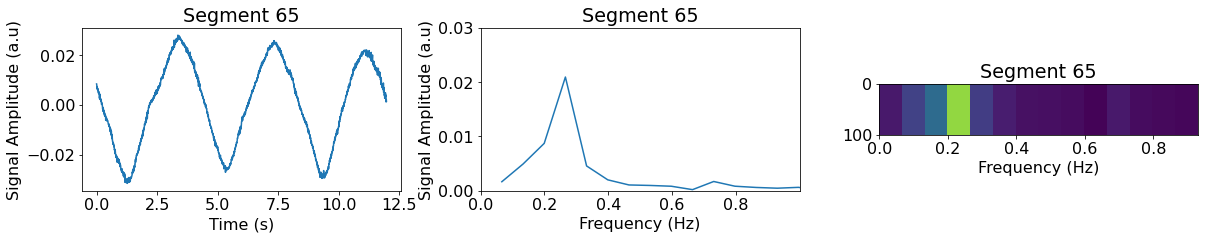

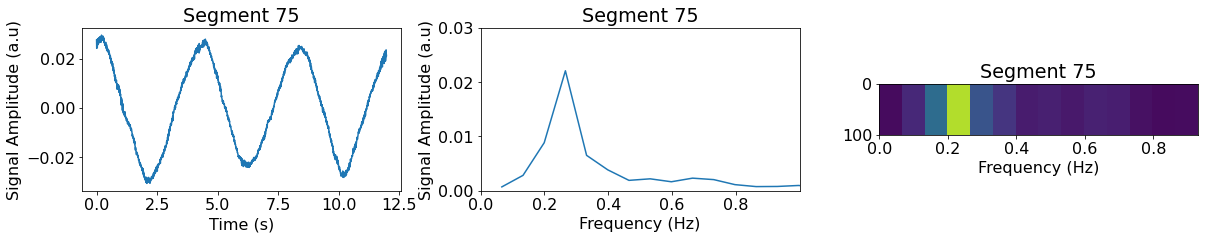

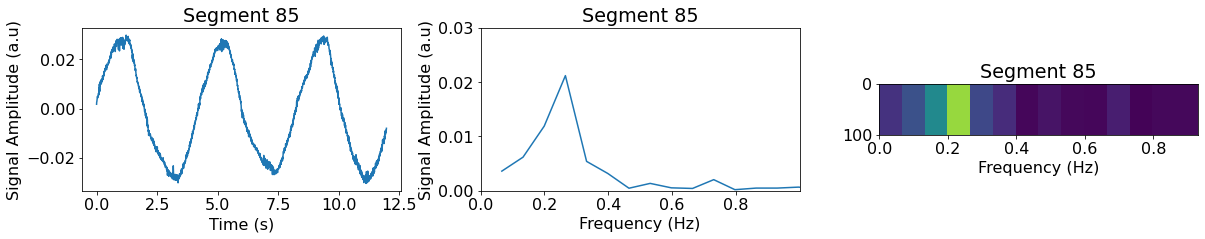

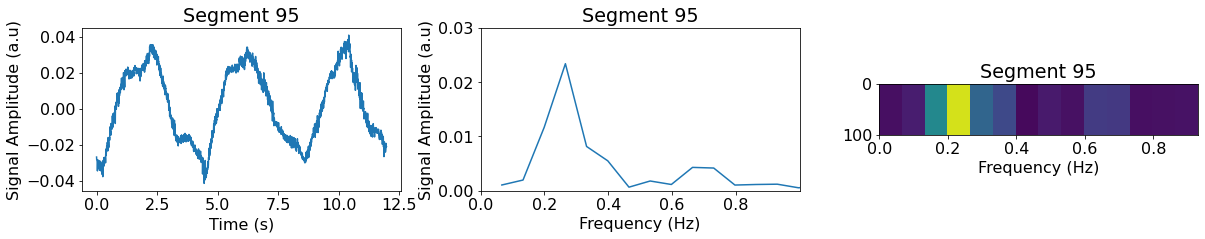

In [12]:
#Now the same but also showing it as image
#to not to have a figure limit
plt.rcParams.update({'figure.max_open_warning': 0})
plt.rcParams.update({'font.size': 16})

#number of sample points: Kts= Kt short
Kts=Kt[:,0:2500]#[:,0:2500]#[:,79640:130700]

N=Kts.shape[1]

#hanning
hann=np.hanning(N)

#sample spacing
T=1.0/167.0
x=np.linspace(0.0, N*T, N)

xf=np.linspace(0.0, 1.0//(2.0*T), N//2)
#xf=scipy.fftpack.fftfreq(N,T)

#creates the writer
output_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_fourier/'
fourierMap=open(os.path.join(output_path,'2020-07-01_14-41-11_chemotaxisl_worm2_fourierMap.csv'),'w', newline='')
csv_writerfourierMap=csv.writer(fourierMap)

for idx, segment in enumerate(Kts):
    #skip some segments
    if idx%10!=5:continue
    
    y=segment
    yf=scipy.fftpack.fft(y)#*hann)
    #define axes
    #y_axis (see that it should start at 1 in yf[1:N//2])
    y_axis=2.0/N * np.abs(yf[1:N//2])
    #x_axis
    x_axis=xf[1:N//2]
    #writer:
    
    #csv_writerfourierMap.writerow(2.0/N * np.abs(yf[1:N//2]))
    
    #define x and y
    x=np.arange(0, y[400:2400].shape[0]/167,1/167)
    y=y[400:2400]
    
    #plotting:
    plotting=1
    if plotting==0:continue
    plt.figure(figsize=(20,3))
    plt.subplot(1,3,1)
    plt.plot(x,y)
    plt.title('Segment '+str(idx))
    plt.xlabel('Time (s)')
    plt.ylabel('Signal Amplitude (a.u)')
    
    #period (ignore)
#     plt.subplot(1,3,2)
#     plt.plot(1/x_axis, y_axis)
#     plt.xlim(0,10)
#     plt.title('Signal Period at segment '+str(idx))
#     plt.xlabel('Period (s)')
#     plt.ylabel('Signal Amplitude (a.u)')
    
    plt.subplot(1,3,2)
    plt.plot(x_axis, y_axis)
    #plt.xlim(0,max(xf[1:N//2]))
    plt.xlim(0,1)
    plt.ylim([0, 0.03])
    plt.xticks(np.arange(0, 1, step=0.2))  
    plt.title('Segment '+str(idx))
    plt.ylabel('Signal Amplitude (a.u)')
    plt.xlabel('Frequency (Hz)')
    
    plt.subplot(1,3,3)
    y_img=np.tile(y_axis, (500, 1))
    plt.imshow(y_img[1:14,0:14], extent=[0,xf[14],100,0], vmin=0, vmax=0.025, aspect=0.0015)
    #plt.yaxis('Off')
    plt.xlabel('Frequency (Hz)')
    plt.title('Segment '+str(idx))


    
    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.25, hspace=0.25)

#fourierMap.close()

In [28]:
csv_skeleton='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-07-01_10-50-18_control_worm2_spline_K.csv'
fourier_transform(csv_skeleton, '.')

2020-07-01_10-50-18_control_wo


In [9]:
fourier_map('2020-07-01_10-50-18_control_woFourierTransform.csv')

NameError: name 'fourier_map' is not defined

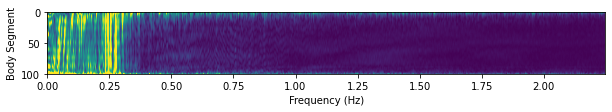

In [11]:
#create FFT 'raster plot' as a script
df=pd.read_csv(os.path.join(output_path,'2020-07-01_14-41-11_chemotaxisl_worm2_fourierMap.csv'), header=None)
df.shape

fig, ax = plt.subplots(figsize=(10,3))
ax.imshow(df.iloc[:,0:1165], extent=[0,xf[1165],100,0], vmin=0, vmax=0.0025, aspect=0.0025)#, cmap='Reds')
plt.colorbar
plt.xlabel('Frequency (Hz)')
plt.ylabel('Body Segment')
plt.savefig(output_path+'2020-07-01_14-41-11_chemotaxisl_worm2_fourierMap.tiff',dpi=600)
plt.show()

## Now I made everything as functions

### Fourier Transform function (and Plotting)

In [10]:
#as a function

#generate Fourier csv file
def fourier_transform(csv_skeleton, output_path):
    filename=re.split('/',csv_skeleton)[-1][:-16]
    print(filename)
    K = np.genfromtxt(csv_skeleton, delimiter=',')
    #to remove nan rows in the data
    K=K[~np.isnan(K).any(axis=1)]
    Kt=K.T
    plt.rcParams.update({'figure.max_open_warning': 0})
    #number of sample points
    #Kts= Kt short
    Kts=Kt#[:,79640:130700]

    N=Kts.shape[1]
    #hanning
    hann=np.hanning(N)
    #sample spacing
    T=1.0/167.0
    x=np.linspace(0.0, N*T, N)
    xf=np.linspace(0.0, 1.0//(2.0*T), N//2)
    #xf=scipy.fftpack.fftfreq(N,T)

    fourierMap=open(os.path.join(output_path,filename)+'FourierTransform.csv','w', newline='')
    csv_writerfourierMap=csv.writer(fourierMap)

    for idx, segment in enumerate(Kts):
        #if idx%5!=0:continue
        y=segment
        yf=scipy.fftpack.fft(y)#*hann)
        #y axis
        y_axis=2.0/N * np.abs(yf[1:N//2])

        #writer:
        csv_writerfourierMap.writerow(y_axis)
        #plotting:
        plotting=0
        if plotting==0:continue
        plt.figure(figsize=(15,3))
        plt.subplot(1,3,1)
        plt.plot(y)
        plt.title('Signal at segment '+str(idx))
        plt.xlabel('Time (frames)')
        plt.ylabel('Signal Amplitude (a.u)')

        plt.subplot(1,3,2)
        plt.plot(1/xf[1:N//2], y_axis)
        plt.xlim(0,10)
        plt.title('Signal Period at segment '+str(idx))
        plt.xlabel('Period (s)')
        plt.ylabel('Signal Amplitude (a.u)')

        plt.subplot(1,3,3)
        plt.plot(xf[1:N//2], y_axis)
        plt.xlim(0,max(xf[1:N//2]))
        plt.xlim(0,2)
        plt.title('Signal Frequency at segment '+str(idx))
        plt.ylabel('Signal Amplitude (a.u)')
        plt.xlabel('Frequency (Hz)')

        plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.25, hspace=0.25)

    fourierMap.close()



### Fourier map

In [11]:
#generate Fourier spectrum map
def fourier_map(csv_fft):
    # output_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_fourier'
    # csv_filepath=os.path.join(output_path,'2020-07-01_14-41-11_chemotaxisl_worm2_fourierMap.csv')
    df=pd.read_csv(csv_fft, header=None)
    #plotting
    fig, ax = plt.subplots(figsize=(10,3))
    ax.imshow(df.iloc[:,0:519], extent=[0,xf[519],100,0], vmin=0, vmax=0.0025, aspect=0.2)#aspect=0.0025)#, cmap='Reds')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Body Segment')
    plt.title(re.split('/',csv_fft)[-1])
    #plt.savefig(re.split('.csv',csv_fft)[0]+'2.tiff',dpi=600)
    plt.show()


In [210]:
#fourier transform
path = '/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/*spline_K.csv'
for fname in glob.glob(path):
    #print (fname)
    fourier_transform(fname, '/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_fourier_good/')

/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-06-30_16-25-56_chemotaxis_worm2_spline_K.csv
2020-06-30_16-25-56_chemotaxis_worm2_spline_K
/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-06-30_17-47-20_chemotaxis_worm4_spline_K.csv
2020-06-30_17-47-20_chemotaxis_worm4_spline_K
/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-06-30_16-54-43_chemotaxis_worm3_spline_K.csv
2020-06-30_16-54-43_chemotaxis_worm3_spline_K
/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-07-01_14-41-11_chemotaxisl_worm2_spline_K.csv
2020-07-01_14-41-11_chemotaxisl_worm2_spline_K
/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-07-01_13-21-00_chemotaxisl_worm1_spline_K.csv
2020-07-01_13-21-00_chemotaxisl_worm1_spline_K
/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-07-01_10-50-18_cont

/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_fourier_good/2020-07-01_10-50-18_control_worm2_FourierTransform.csv


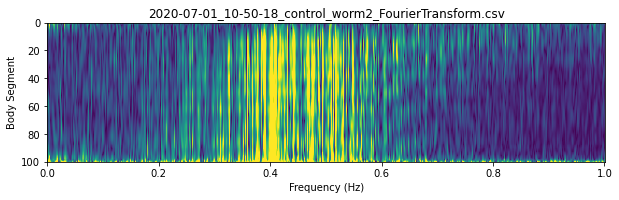

/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_fourier_good/2020-07-01_11-50-53_control_worm3_FourierTransform.csv


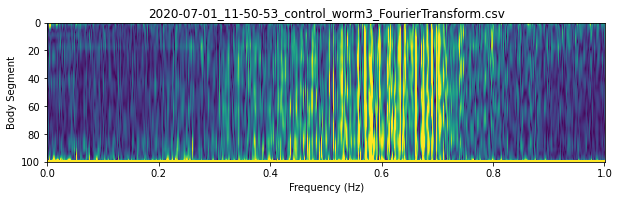

/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_fourier_good/2020-07-01_17-32-12_control_worm4_FourierTransform.csv


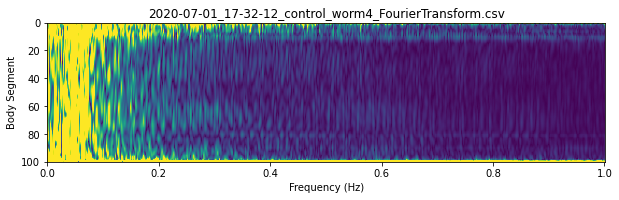

/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_fourier_good/2020-07-01_17-58-13_control_worm5_FourierTransform.csv


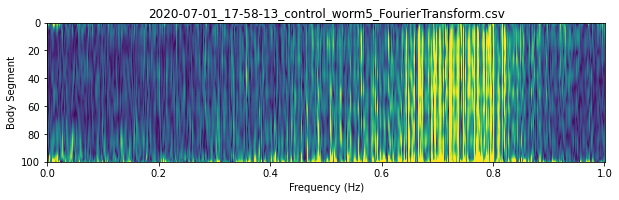

/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_fourier_good/2020-07-01_18-36-25_control_worm6_FourierTransform.csv


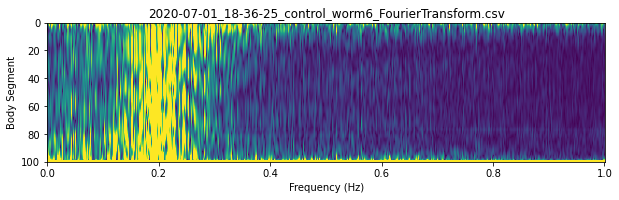

/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_fourier_good/2020-07-01_10-10-48_control_worm1_FourierTransform.csv


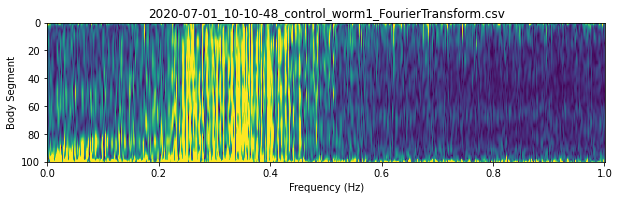

/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_fourier_good/2020-06-30_16-25-56_chemotaxis_worm2_FourierTransform.csv


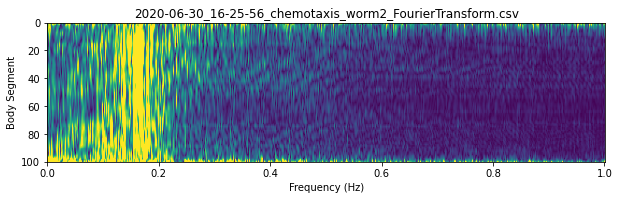

/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_fourier_good/2020-06-30_16-54-43_chemotaxis_worm3_FourierTransform.csv


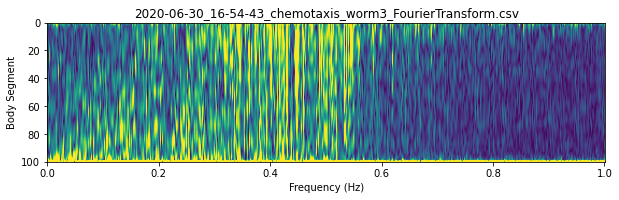

/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_fourier_good/2020-06-30_17-47-20_chemotaxis_worm4_FourierTransform.csv


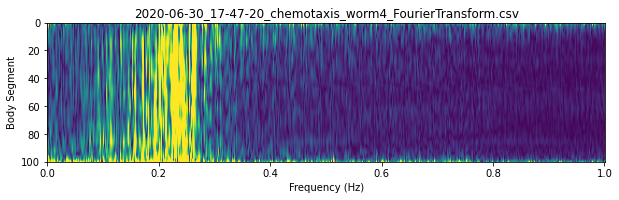

/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_fourier_good/2020-06-30_18-17-47_chemotaxis_worm5_FourierTransform.csv


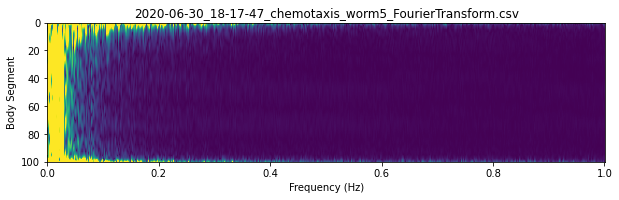

/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_fourier_good/2020-07-01_13-21-00_chemotaxisl_worm1_FourierTransform.csv


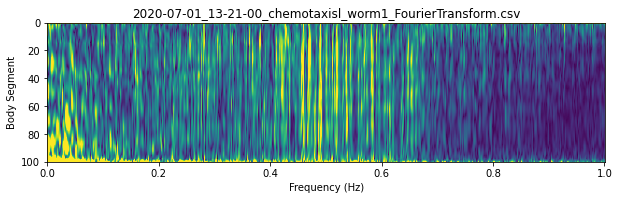

/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_fourier_good/2020-07-01_14-41-11_chemotaxisl_worm2_FourierTransform.csv


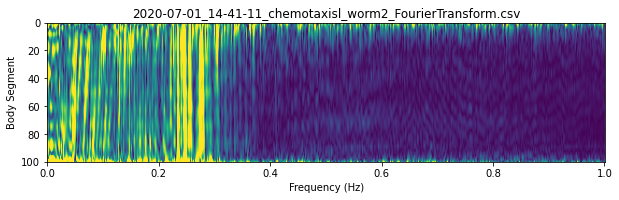

/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_fourier_good/2020-07-01_15-13-35_chemotaxisl_worm3_FourierTransform.csv


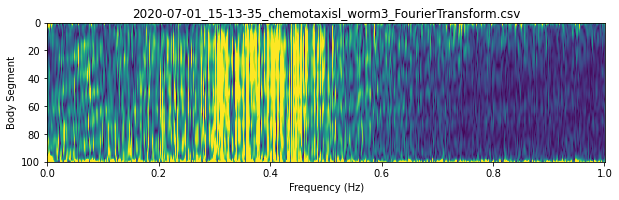

/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_fourier_good/2020-07-01_15-42-06_chemotaxisl_worm4_FourierTransform.csv


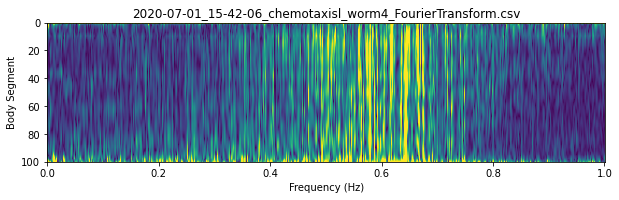

/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_fourier_good/2020-07-01_16-20-36_chemotaxisl_worm5_FourierTransform.csv


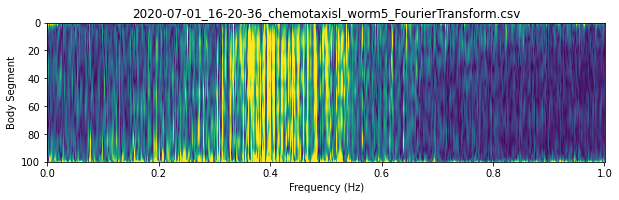

/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_fourier_good/2020-07-01_17-01-27_chemotaxis_worm6_FourierTransform.csv


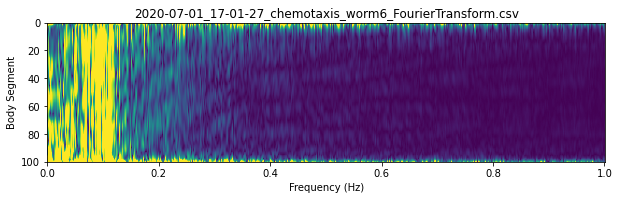

/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_fourier_good/2020-06-30_15-48-51_chemotaxis_worm1_FourierTransform.csv


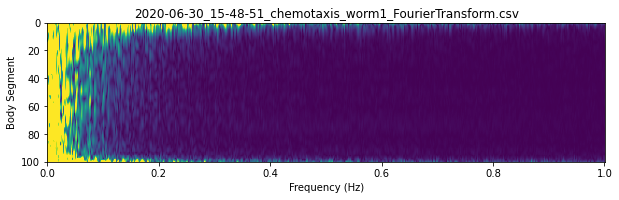

In [224]:
#fouriermap
path = '/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_fourier_good/*.csv'
for fname in glob.glob(path):
    #print (fname)
    fourier_map(fname)